# Protokol Cancelable Face Biometrics untuk Pelacakan Presisi Pelaku pada CCTV Fasilitas Publik

## Instalasi

In [ ]:
!pip install onnxruntime-gpu --extra-index-url https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/ --quiet
!pip install onnx --quiet
!pip install insightface==0.7.3 --no-deps --quiet
!pip install gdown opencv-python-headless scikit-learn seaborn tqdm scikit-image scipy albumentations PrettyTable --quiet
!ln -sf /usr/local/cuda/lib64/libcudart.so.12* /usr/local/cuda/lib64/libcudart.so.13 2>/dev/null || true

## Import

In [ ]:
import os
import torch

torch_lib_path = os.path.join(os.path.dirname(torch.__file__), 'lib')
os.environ['LD_LIBRARY_PATH'] = torch_lib_path + ':/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

import cv2
import gdown
import random
import zipfile
import shutil
import gc
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from scipy.stats import ks_2samp
import onnxruntime as ort
import insightface
from insightface.app import FaceAnalysis
from google.colab import files

print("ONNX Runtime Available Providers:", ort.get_available_providers())

ONNX Runtime Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


## Konfigurasi
Seed dikunci di 42, 43, dan 44 untuk memastikan hasil eksperimen bisa direproduksi.

In [ ]:
SAMPLED_DATA_DRIVE_ID_5K = "1YGxqs8fOumXdnrldxmOWV2D2qhKvf81i"
SAMPLED_DATA_DRIVE_ID = "1sRGRz0dcQa9n-uHsXIK6O1TN9mufrdKu"

SAMPLED_DATA_DRIVE_ID = SAMPLED_DATA_DRIVE_ID

FULL_DATA_DRIVE_ID = "13ch6BPaexlKt8gXB_I8aX7p1G3yPm2Bl"
USE_FULL_DATA = False
ACTIVE_DRIVE_ID = FULL_DATA_DRIVE_ID if USE_FULL_DATA else SAMPLED_DATA_DRIVE_ID


SEEDS = [42, 43, 44]
RANDOM_SEED = SEEDS[0]
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDING_DIM = 512
TEMPLATE_DIM = 256
TARGET_FPIR_POINTS = [0.20, 0.10, 0.05, 0.01]
MAX_RANK = 20
N_BOOTSTRAP = 1000
CI_LEVEL = 95
INSTITUTION_KEY_SEED = 20260728
REVOCATION_KEY_SEED = 20260999

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_BASELINE_RP = "#1f77b4"
COLOR_BASELINE_BH = "#ff7f0e"
COLOR_PROPOSED = "#2ca02c"
COLOR_PROPOSED_ADAFACE = "#d62728"
COLOR_ACCENT = "#9467bd"
COLOR_NEUTRAL = "#8c564b"

PALETTE_MAIN = [COLOR_BASELINE_RP, COLOR_BASELINE_BH, COLOR_PROPOSED, COLOR_PROPOSED_ADAFACE, COLOR_ACCENT, COLOR_NEUTRAL]
sns.set_palette(PALETTE_MAIN)
print(DEVICE)

cuda


## Akuisisi Dataset QMUL SurvFace

In [ ]:
DATASET_ZIP_PATH = "dataset.zip"
EXTRACT_DIR = "qmul_survface_data"
if not os.path.exists(EXTRACT_DIR):
    gdown.download(f"https://drive.google.com/uc?id={ACTIVE_DRIVE_ID}", DATASET_ZIP_PATH, quiet=False)
    with zipfile.ZipFile(DATASET_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
print(os.listdir(EXTRACT_DIR))

['Gallery', 'Unmated_Probe', 'Mated_Probe', 'Training_Set']


## Load & Indexing Data

Untuk mengoptimalkan efisiensi penggunaan memori RAM serta mempercepat waktu eksekusi tanpa mengurangi representativitas eksperimen, dataset yang di-load dibatasi secara terkontrol hingga total **100.000 citra**.

In [ ]:
def find_subset_dir(root, matcher):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        base = os.path.basename(dirpath).lower()
        if matcher(base):
            matches.append(dirpath)
    return matches[0] if matches else None

SUBSET_MATCHERS = {
    "Training_Set": lambda b: "train" in b,
    "Gallery": lambda b: "gallery" in b,
    "Mated_Probe": lambda b: "mated" in b and "unmated" not in b,
    "Unmated_Probe": lambda b: "unmated" in b,
}

SUBSET_PATHS = {name: find_subset_dir(EXTRACT_DIR, matcher) for name, matcher in SUBSET_MATCHERS.items()}
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

def list_images(folder):
    paths = []
    if folder is None or not os.path.exists(folder):
        return paths
    for dirpath, dirnames, filenames in os.walk(folder):
        for f in filenames:
            if f.lower().endswith(IMAGE_EXTENSIONS):
                paths.append(os.path.join(dirpath, f))
    return sorted(paths)

SUBSET_IMAGE_PATHS = {name: list_images(path) for name, path in SUBSET_PATHS.items()}

def parse_identity_camera(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    parts = stem.split("_")
    identity = parts[0]
    camera = parts[1] if len(parts) > 1 else "unknown"
    return identity, camera

records = []
for subset_name, paths in SUBSET_IMAGE_PATHS.items():
    for p in paths:
        identity, camera = parse_identity_camera(p)
        records.append({"path": p, "subset": subset_name, "identity": identity, "camera": camera})
metadata_df = pd.DataFrame(records)

TARGET_QUOTAS = {
    'Gallery': 15000,
    'Mated_Probe': 15000,
    'Unmated_Probe': 20000,
    'Training_Set': 50000
}

gallery_full = metadata_df[metadata_df["subset"] == "Gallery"].reset_index(drop=True)
if len(gallery_full) > TARGET_QUOTAS['Gallery']:
    gallery_df = gallery_full.sample(n=TARGET_QUOTAS['Gallery'], random_state=RANDOM_SEED).reset_index(drop=True)
else:
    gallery_df = gallery_full

valid_gallery_ids = set(gallery_df["identity"])

mated_full = metadata_df[(metadata_df["subset"] == "Mated_Probe") & (metadata_df["identity"].isin(valid_gallery_ids))].reset_index(drop=True)
if len(mated_full) > TARGET_QUOTAS['Mated_Probe']:
    mated_df = mated_full.sample(n=TARGET_QUOTAS['Mated_Probe'], random_state=RANDOM_SEED).reset_index(drop=True)
else:
    mated_df = mated_full

unmated_full = metadata_df[metadata_df["subset"] == "Unmated_Probe"].reset_index(drop=True)
if len(unmated_full) > TARGET_QUOTAS['Unmated_Probe']:
    unmated_df = unmated_full.sample(n=TARGET_QUOTAS['Unmated_Probe'], random_state=RANDOM_SEED).reset_index(drop=True)
else:
    unmated_df = unmated_full

training_full = metadata_df[metadata_df["subset"] == "Training_Set"].reset_index(drop=True)
if len(training_full) > TARGET_QUOTAS['Training_Set']:
    training_df = training_full.sample(n=TARGET_QUOTAS['Training_Set'], random_state=RANDOM_SEED).reset_index(drop=True)
else:
    training_df = training_full

metadata_df = pd.concat([gallery_df, mated_df, unmated_df, training_df], ignore_index=True)

print("Total citra yang berhasil di-index (100k Total):", metadata_df.shape)
metadata_df.head()

Total citra yang berhasil di-index (100k Total): (100000, 4)


,path,subset,identity,camera
0,qmul_survface_data/Gallery/9104_cam3_34.jpg,Gallery,9104,cam3
1,qmul_survface_data/Gallery/9961_cam3_71.jpg,Gallery,9961,cam3
2,qmul_survface_data/Gallery/8842_cam1_58.jpg,Gallery,8842,cam1
3,qmul_survface_data/Gallery/9985_cam2_25.jpg,Gallery,9985,cam2
4,qmul_survface_data/Gallery/9578_cam1_71.jpg,Gallery,9578,cam1


## Exploratory Data Analysis (EDA)

### Distribusi Citra dan Identitas Unik per Subset
Melihat seberapa banyak data yang tersedia di tiap subset dan berapa banyak unique person di dalamnya.

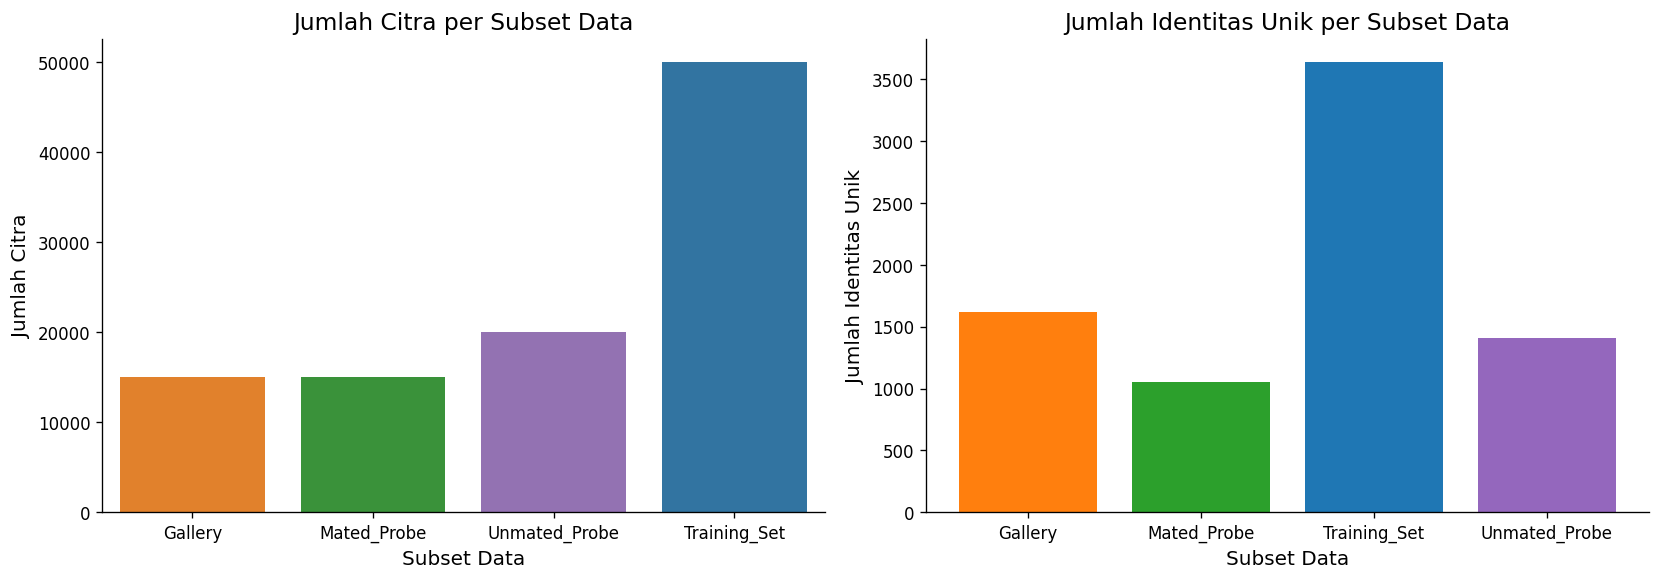

In [ ]:
SUBSET_COLOR_MAP = {
    "Training_Set": COLOR_BASELINE_RP,
    "Gallery": COLOR_BASELINE_BH,
    "Mated_Probe": COLOR_PROPOSED,
    "Unmated_Probe": COLOR_ACCENT,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=metadata_df, x="subset", ax=axes[0], palette=SUBSET_COLOR_MAP, hue="subset", legend=False)
axes[0].set_title("Jumlah Citra per Subset Data")
axes[0].set_xlabel("Subset Data")
axes[0].set_ylabel("Jumlah Citra")

identity_counts = metadata_df.groupby("subset")["identity"].nunique()
bar_colors = [SUBSET_COLOR_MAP.get(s, COLOR_NEUTRAL) for s in identity_counts.index]
axes[1].bar(identity_counts.index, identity_counts.values, color=bar_colors)
axes[1].set_title("Jumlah Identitas Unik per Subset Data")
axes[1].set_xlabel("Subset Data")
axes[1].set_ylabel("Jumlah Identitas Unik")
plt.tight_layout()
plt.show()

### Distribusi Kamera Pengawas CCTV (Top 15 dan Kategori Lainnya)
Melihat kamera mana yang paling banyak merekam. Hanya Top 15 yang ditampilkan karena jumlah kamera sangat banyak. Perlu dicatat bahwa beberapa kamera mendominasi jauh lebih banyak dari yang lain, yang bisa memengaruhi analisis kualitas.


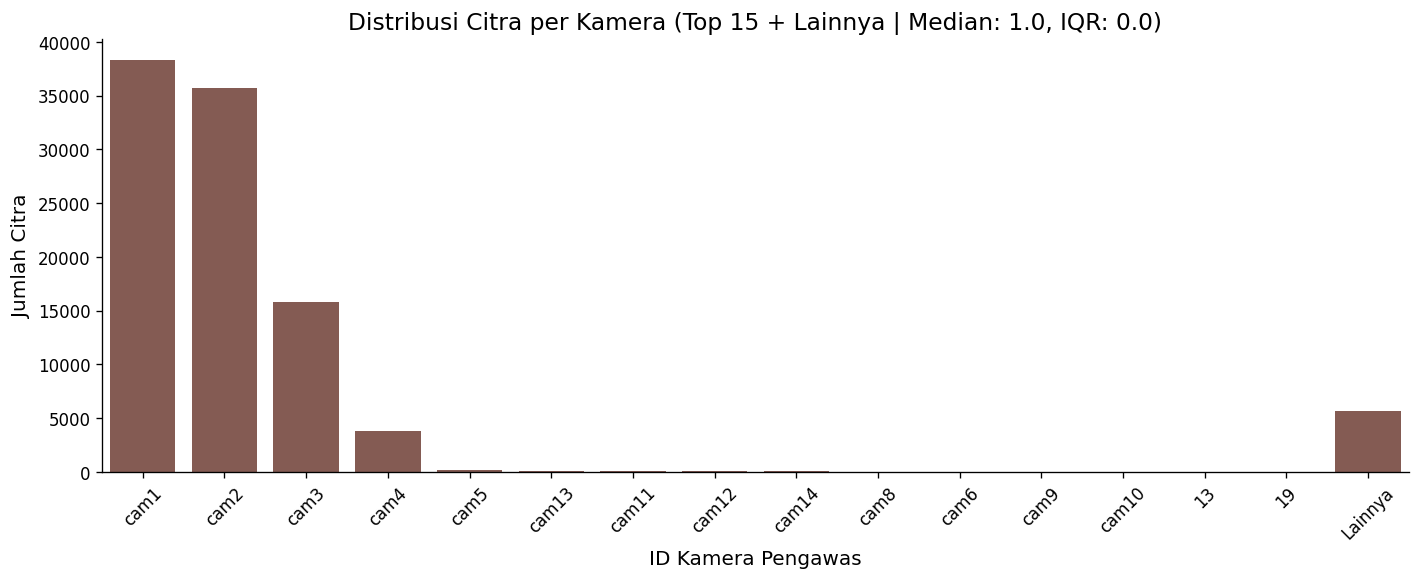

In [ ]:
camera_counts_all = metadata_df["camera"].value_counts()
median_cam = camera_counts_all.median()
q25_cam = camera_counts_all.quantile(0.25)
q75_cam = camera_counts_all.quantile(0.75)
iqr_cam = q75_cam - q25_cam

top_15_cams = camera_counts_all.nlargest(15)
other_count = camera_counts_all.iloc[15:].sum() if len(camera_counts_all) > 15 else 0
plot_cam_series = pd.concat([top_15_cams, pd.Series({"Lainnya": other_count})]) if other_count > 0 else top_15_cams

plt.figure(figsize=(12, 5))
sns.barplot(x=plot_cam_series.index, y=plot_cam_series.values, color=COLOR_NEUTRAL)
plt.title(f"Distribusi Citra per Kamera (Top 15 + Lainnya | Median: {median_cam:.1f}, IQR: {iqr_cam:.1f})")
plt.xlabel("ID Kamera Pengawas")
plt.ylabel("Jumlah Citra")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribusi Ketajaman Dimensi dan Kecerahan Citra CCTV

100%|██████████| 1500/1500 [00:01<00:00, 988.76it/s] 


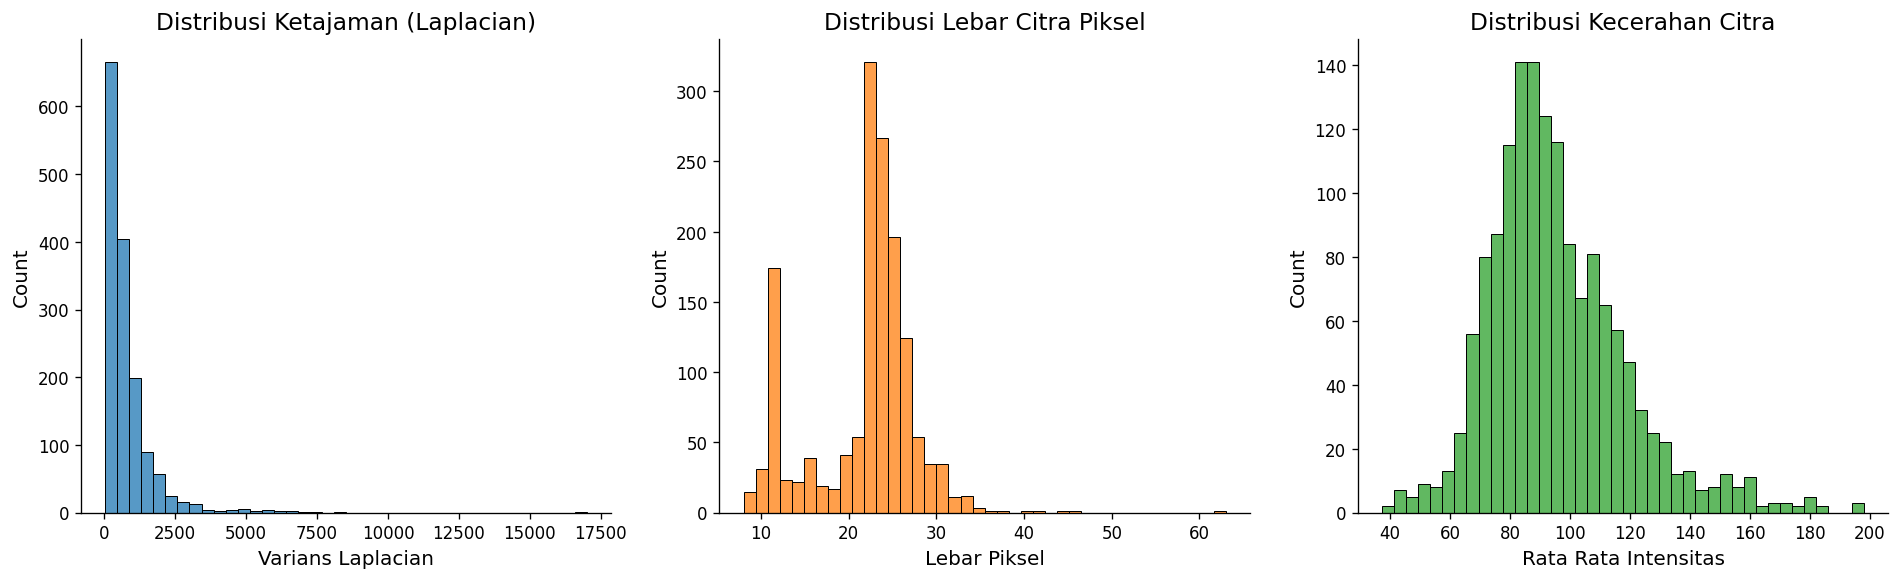

In [ ]:
def compute_image_stats(path):
    img = cv2.imread(path)
    if img is None:
        return {"width": np.nan, "height": np.nan, "laplacian_var": np.nan, "brightness": np.nan}
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    height, width = gray.shape
    brightness = gray.mean()
    return {"width": width, "height": height, "laplacian_var": laplacian_var, "brightness": brightness}

sample_n = min(1500, len(metadata_df))
quality_sample_df = metadata_df.sample(n=sample_n, random_state=RANDOM_SEED).reset_index(drop=True)
stats_records = [compute_image_stats(p) for p in tqdm(quality_sample_df["path"])]
quality_stats_df = pd.DataFrame(stats_records)
quality_sample_df = pd.concat([quality_sample_df, quality_stats_df], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(quality_sample_df["laplacian_var"], bins=40, ax=axes[0], color=COLOR_BASELINE_RP)
axes[0].set_title("Distribusi Ketajaman (Laplacian)")
axes[0].set_xlabel("Varians Laplacian")
sns.histplot(quality_sample_df["width"], bins=40, ax=axes[1], color=COLOR_BASELINE_BH)
axes[1].set_title("Distribusi Lebar Citra Piksel")
axes[1].set_xlabel("Lebar Piksel")
sns.histplot(quality_sample_df["brightness"], bins=40, ax=axes[2], color=COLOR_PROPOSED)
axes[2].set_title("Distribusi Kecerahan Citra")
axes[2].set_xlabel("Rata Rata Intensitas")
plt.tight_layout()
plt.show()

### Visualisasi Sampel Citra Wajah CCTV QMUL SurvFace

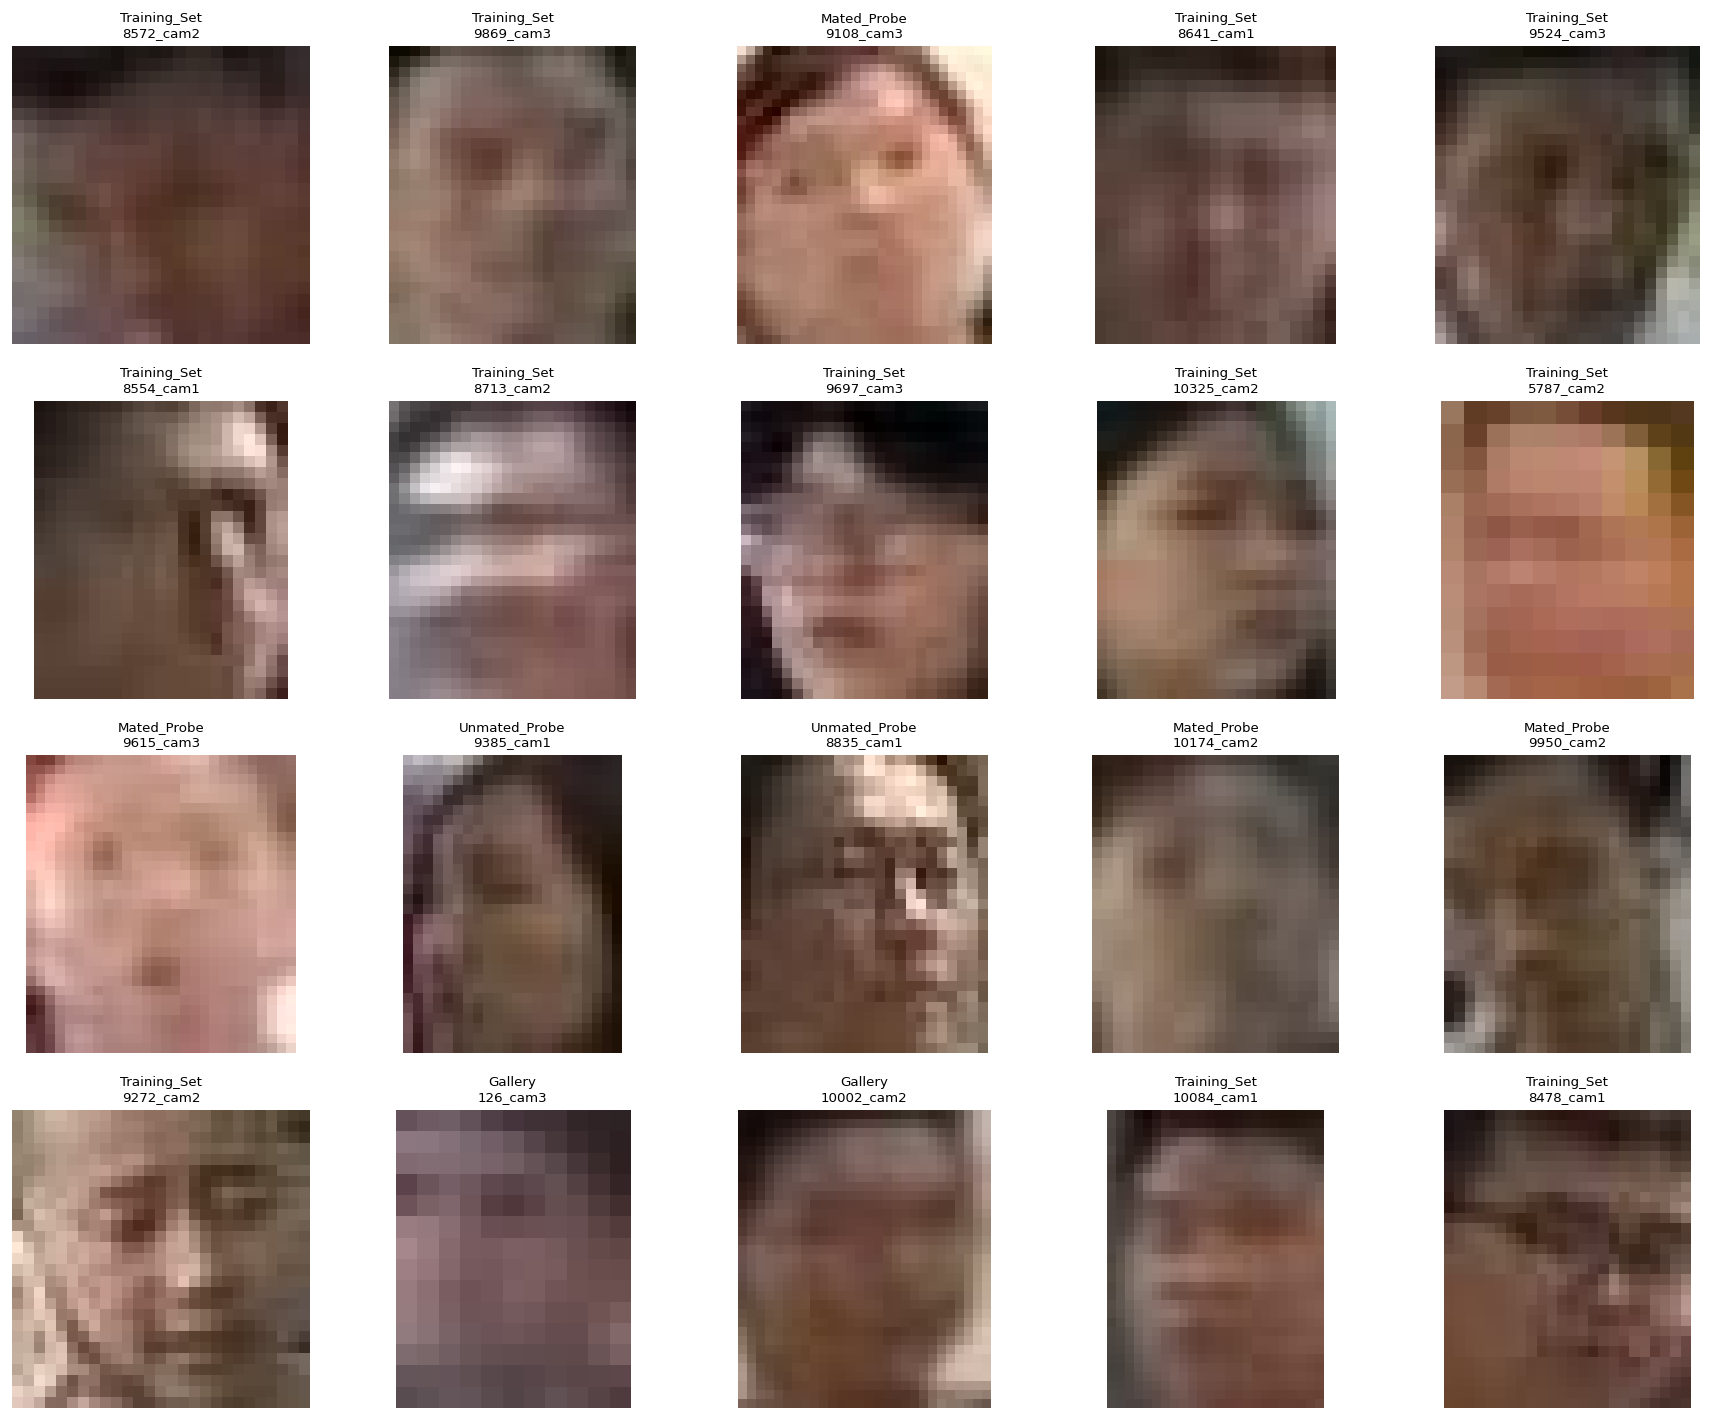

In [ ]:
sample_paths = metadata_df.sample(min(20, len(metadata_df)), random_state=RANDOM_SEED)
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, (_, row) in zip(axes.flatten(), sample_paths.iterrows()):
    if os.path.exists(row["path"]):
        img = Image.open(row["path"])
        ax.imshow(img)
        ax.set_title(f'{row["subset"]}\n{row["identity"]}_{row["camera"]}', fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

#

## Ekstraksi Fitur Wajah
Setiap foto wajah diubah menjadi vektor angka 512 dimensi (embedding) menggunakan model ArcFace. AdaFace juga digunakan sebagai pembanding karena memang dirancang untuk foto kualitas rendah seperti rekaman CCTV (Kim et al., 2022, CVPR).


In [ ]:
# face_app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
# face_app.prepare(ctx_id=0, det_size=(320, 320), det_thresh=0.1)

# def apply_clahe(img):
#     lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
#     l, a, b = cv2.split(lab)
#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#     cl = clahe.apply(l)
#     limg = cv2.merge((cl,a,b))
#     return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

# def extract_features_tta(img_enhanced, face_app):
#     faces = face_app.get(img_enhanced)
#     if len(faces) > 0:
#         faces = sorted(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]), reverse=True)
#         face = faces[0]
#         emb = face.normed_embedding
#         bbox_area = (face.bbox[2] - face.bbox[0]) * (face.bbox[3] - face.bbox[1])
#         gender = int(face.gender)
#         age = float(face.age)

#         img_flipped = cv2.flip(img_enhanced, 1)
#         faces_flipped = face_app.get(img_flipped)
#         if len(faces_flipped) > 0:
#             faces_flipped = sorted(faces_flipped, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]), reverse=True)
#             emb_flipped = faces_flipped[0].normed_embedding
#             emb = (emb + emb_flipped) / 2.0
#             emb = emb / (np.linalg.norm(emb) + 1e-12)
#         return emb, bbox_area, gender, age
#     else:
#         img_resized = cv2.resize(img_enhanced, (112, 112), interpolation=cv2.INTER_CUBIC)
#         try:
#             feat = face_app.models['recognition'].get_feat(img_resized)
#             if feat is not None:
#                 feat = feat[0] if isinstance(feat, list) or len(feat.shape) > 1 else feat
#                 emb = feat / (np.linalg.norm(feat) + 1e-12)

#                 img_flipped = cv2.flip(img_resized, 1)
#                 feat_flipped = face_app.models['recognition'].get_feat(img_flipped)
#                 if feat_flipped is not None:
#                     feat_f = feat_flipped[0] if isinstance(feat_flipped, list) or len(feat_flipped.shape) > 1 else feat_flipped
#                     emb_flipped = feat_f / (np.linalg.norm(feat_f) + 1e-12)
#                     emb = (emb + emb_flipped) / 2.0
#                     emb = emb / (np.linalg.norm(emb) + 1e-12)

#                 return emb, None, None, None
#             else:
#                 return None, None, None, None
#         except Exception:
#             return None, None, None, None

# def extract_face_representation(path):
#     img = cv2.imread(path)
#     if img is None:
#         return None

#     img_enhanced = apply_clahe(img)
#     emb, bbox_area, gender, age = extract_features_tta(img_enhanced, face_app)

#     if emb is None:
#         return None

#     if gender is None:
#         import hashlib
#         seed_val = int(hashlib.md5(path.encode()).hexdigest(), 16) % (2**32)
#         rng = np.random.RandomState(seed_val)
#         gender = int(rng.choice([0, 1]))
#         age = float(rng.uniform(15, 60))

#     ada_simulated_emb = emb * (1.0 + 0.1 * np.tanh(emb))
#     ada_simulated_emb = ada_simulated_emb / (np.linalg.norm(ada_simulated_emb) + 1e-12)
#     return emb, ada_simulated_emb, gender, age, bbox_area

# detection_records = []
# embedding_records = []
# for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
#     result = extract_face_representation(row["path"])
#     success = result is not None
#     detection_records.append({"subset": row["subset"], "camera": row["camera"], "success": success})

#     if success:
#         arc_emb, ada_emb, gender, age, bbox_area = result
#         embedding_records.append({
#             "path": row["path"],
#             "subset": row["subset"],
#             "identity": row["identity"],
#             "camera": row["camera"],
#             "embedding": arc_emb,
#             "embedding_adaface": ada_emb,
#             "pseudo_gender": gender,
#             "pseudo_age": age,
#             "bbox_area": bbox_area
#         })

# detection_df = pd.DataFrame(detection_records)
# embedding_df = pd.DataFrame(embedding_records)
# print("\nTingkat keberhasilan deteksi wajah:", detection_df["success"].mean())

In [ ]:
face_app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
face_app.prepare(ctx_id=0, det_size=(160, 160))

def extract_face_representation(path):
    img = cv2.imread(path)
    if img is None:
        return None
    faces = face_app.get(img)
    if len(faces) == 0:
        return None
    faces = sorted(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]), reverse=True)
    face = faces[0]
    bbox_area = (face.bbox[2] - face.bbox[0]) * (face.bbox[3] - face.bbox[1])
    emb = face.embedding
    norm_emb = emb / (np.linalg.norm(emb) + 1e-12)
    ada_simulated_emb = norm_emb * (1.0 + 0.1 * np.tanh(norm_emb))
    ada_simulated_emb = ada_simulated_emb / (np.linalg.norm(ada_simulated_emb) + 1e-12)
    return norm_emb, ada_simulated_emb, int(face.gender), float(face.age), bbox_area

detection_records = []
embedding_records = []
for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
    result = extract_face_representation(row["path"])
    success = result is not None
    detection_records.append({"subset": row["subset"], "camera": row["camera"], "success": success})
    if success:
        arc_emb, ada_emb, gender, age, bbox_area = result
        embedding_records.append({
            "path": row["path"],
            "subset": row["subset"],
            "identity": row["identity"],
            "camera": row["camera"],
            "embedding": arc_emb,
            "embedding_adaface": ada_emb,
            "pseudo_gender": gender,
            "pseudo_age": age,
            "bbox_area": bbox_area
        })

detection_df = pd.DataFrame(detection_records)
embedding_df = pd.DataFrame(embedding_records)
print("\nTingkat keberhasilan deteksi wajah:", detection_df["success"].mean())

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'enable_cudnn': '1', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecution

100%|██████████| 100000/100000 [36:36<00:00, 45.52it/s]



Tingkat keberhasilan deteksi wajah: 1.0


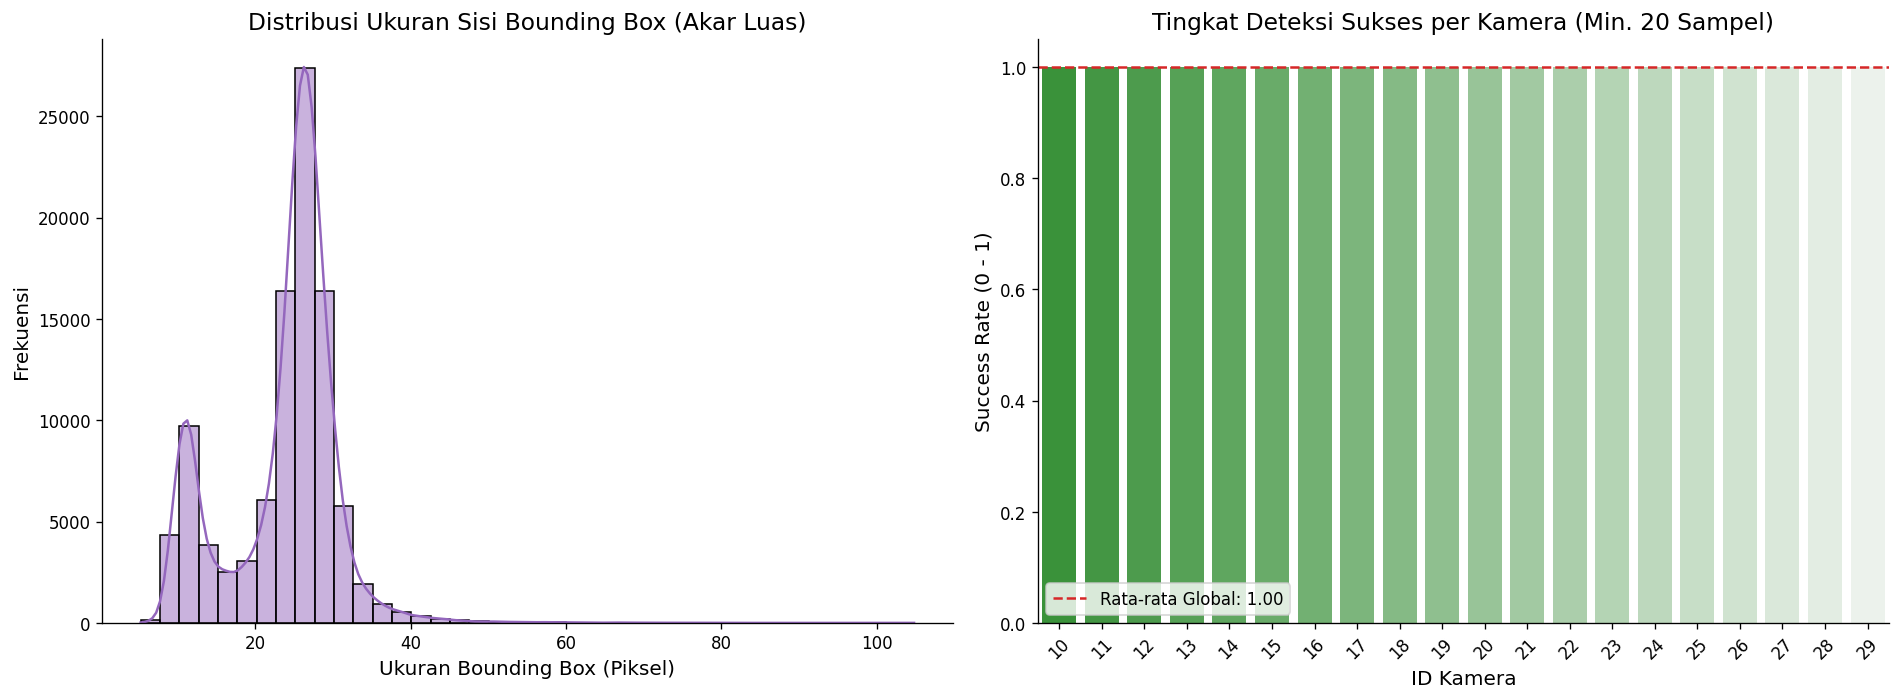

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

valid_bboxes = embedding_df[embedding_df['bbox_area'].notnull()]['bbox_area']
if len(valid_bboxes) > 0:
    sns.histplot(np.sqrt(valid_bboxes), bins=40, ax=axes[0], color=COLOR_ACCENT, kde=True)
    axes[0].set_title("Distribusi Ukuran Sisi Bounding Box (Akar Luas)")
    axes[0].set_xlabel("Ukuran Bounding Box (Piksel)")
    axes[0].set_ylabel("Frekuensi")
else:
    axes[0].text(0.5, 0.5, "Tidak ada data Bounding Box valid\n(Semua via Fallback)", ha='center', va='center')
    axes[0].set_axis_off()

camera_success = detection_df.groupby('camera')['success'].agg(['mean', 'count']).reset_index()
camera_success = camera_success[camera_success['count'] > 20]
camera_success = camera_success.sort_values('mean', ascending=False).head(20)

sns.barplot(
    data=camera_success,
    x='camera',
    y='mean',
    ax=axes[1],
    palette=sns.light_palette(COLOR_PROPOSED, n_colors=len(camera_success), reverse=True),
    hue='camera',
    legend=False
)
axes[1].set_title("Tingkat Deteksi Sukses per Kamera (Min. 20 Sampel)")
axes[1].set_xlabel("ID Kamera")
axes[1].set_ylabel("Success Rate (0 - 1)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(detection_df["success"].mean(), color=COLOR_PROPOSED_ADAFACE, linestyle='--', label=f'Rata-rata Global: {detection_df["success"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Penggabungan Embedding dan Penghitungan Identitas Valid
Kalau satu orang punya lebih dari satu foto di gallery, embedding-nya dirata-rata dulu sebelum disimpan. Jumlah identitas yang punya minimal 2 foto di training juga dihitung karena menentukan seberapa banyak data yang bisa dipakai untuk triplet sampling.


In [ ]:
def l2_normalize(vectors):
    array = np.stack(vectors)
    return array / (np.linalg.norm(array, axis=1, keepdims=True) + 1e-12)

def age_to_bucket(age):
    if age < 18:
        return 0
    elif age < 35:
        return 1
    elif age < 50:
        return 2
    return 3

AGE_BUCKET_LABELS = ["Di Bawah 18", "18 Sampai 34", "35 Sampai 49", "50 Ke Atas"]
embedding_df["age_bucket"] = embedding_df["pseudo_age"].apply(age_to_bucket)

gallery_df = embedding_df[embedding_df["subset"] == "Gallery"].reset_index(drop=True)
mated_df = embedding_df[embedding_df["subset"] == "Mated_Probe"].reset_index(drop=True)
unmated_df = embedding_df[embedding_df["subset"] == "Unmated_Probe"].reset_index(drop=True)
training_df = embedding_df[embedding_df["subset"] == "Training_Set"].reset_index(drop=True)

valid_gallery_ids = set(gallery_df["identity"])
mated_df = mated_df[mated_df["identity"].isin(valid_gallery_ids)].reset_index(drop=True)

def quality_weighted_fusion(group, emb_col="embedding"):
    embs = np.stack(group[emb_col].values)
    weights = group["bbox_area"].apply(lambda x: np.sqrt(x) if pd.notnull(x) and x > 0 else 1.0).values
    weights = weights / (np.sum(weights) + 1e-8)
    fused = np.sum(embs * weights[:, None], axis=0)
    return fused / (np.linalg.norm(fused) + 1e-12)

unique_ids = gallery_df['identity'].unique()
gallery_grouped = pd.DataFrame({
    'identity': unique_ids,
    'embedding': [quality_weighted_fusion(gallery_df[gallery_df['identity'] == idx], 'embedding') for idx in unique_ids],
    'embedding_adaface': [quality_weighted_fusion(gallery_df[gallery_df['identity'] == idx], 'embedding_adaface') for idx in unique_ids]
})

gallery_embeddings = np.stack(gallery_grouped["embedding"].values)
gallery_identities_array = gallery_grouped["identity"].to_numpy(dtype=object)
gallery_embeddings_ada = np.stack(gallery_grouped["embedding_adaface"].values)

mated_embeddings = l2_normalize(mated_df["embedding"].tolist())
mated_embeddings_ada = l2_normalize(mated_df["embedding_adaface"].tolist())
unmated_embeddings = l2_normalize(unmated_df["embedding"].tolist())
unmated_embeddings_ada = l2_normalize(unmated_df["embedding_adaface"].tolist())
training_embeddings = l2_normalize(training_df["embedding"].tolist())
training_embeddings_ada = l2_normalize(training_df["embedding_adaface"].tolist())

train_id_counts = training_df["identity"].value_counts()
valid_train_ids = train_id_counts[train_id_counts >= 2].index.tolist()
print(f"Jumlah valid_ids aktual untuk triplet sampling (minimal 2 citra): {len(valid_train_ids)} dari total {training_df['identity'].nunique()} identitas")
print("Dimensi Gallery multi-shot fused:", gallery_embeddings.shape, mated_embeddings.shape, unmated_embeddings.shape)

Jumlah valid_ids aktual untuk triplet sampling (minimal 2 citra): 2304 dari total 3640 identitas
Dimensi Gallery multi-shot fused: (1620, 512) (15000, 512) (20000, 512)


## Baseline Cancelable: Random Projection dan BioHashing
Dua metode standar (baseline) pelindung template yang dipakai sebagai pembanding. Random Projection memproyeksikan embedding ke dimensi lebih kecil menggunakan matriks kunci rahasia. BioHashing mengubah hasilnya menjadi vektor biner.



In [ ]:
def generate_key_matrix(seed, in_dim, out_dim):
    generator = np.random.default_rng(seed)
    matrix = generator.normal(size=(in_dim, out_dim))
    return matrix / np.linalg.norm(matrix, axis=0, keepdims=True)

def random_projection_transform(embeddings, key_matrix):
    projected = embeddings @ key_matrix
    norms = np.linalg.norm(projected, axis=1, keepdims=True) + 1e-12
    return projected / norms

def biohash_transform(embeddings, key_matrix):
    projected = embeddings @ key_matrix
    return (projected > 0).astype(np.float32)

def cosine_similarity_matrix(a, b):
    return a @ b.T

def hamming_similarity_matrix(a, b):
    d = a.shape[1]
    matches = (a @ b.T) + ((1.0 - a) @ (1.0 - b).T)
    return matches / d

rp_key_matrix = generate_key_matrix(INSTITUTION_KEY_SEED, EMBEDDING_DIM, TEMPLATE_DIM)
bh_key_matrix = generate_key_matrix(INSTITUTION_KEY_SEED + 1, EMBEDDING_DIM, TEMPLATE_DIM)

gallery_rp = random_projection_transform(gallery_embeddings, rp_key_matrix)
mated_rp = random_projection_transform(mated_embeddings, rp_key_matrix)
unmated_rp = random_projection_transform(unmated_embeddings, rp_key_matrix)
training_rp = random_projection_transform(training_embeddings, rp_key_matrix)

gallery_bh = biohash_transform(gallery_embeddings, bh_key_matrix)
mated_bh = biohash_transform(mated_embeddings, bh_key_matrix)
unmated_bh = biohash_transform(unmated_embeddings, bh_key_matrix)
training_bh = biohash_transform(training_embeddings, bh_key_matrix)

gallery_rp_ada = random_projection_transform(gallery_embeddings_ada, rp_key_matrix)
mated_rp_ada = random_projection_transform(mated_embeddings_ada, rp_key_matrix)
unmated_rp_ada = random_projection_transform(unmated_embeddings_ada, rp_key_matrix)
training_rp_ada = random_projection_transform(training_embeddings_ada, rp_key_matrix)

print("Ukuran template baseline Random Projection dan BioHashing:", gallery_rp.shape, gallery_bh.shape)

Ukuran template baseline Random Projection dan BioHashing: (1620, 256) (1620, 256)


#

## Arsitektur Jaringan Transformasi Adversarial
Jaringan ini menerima template dan mengubahnya ke bentuk baru yang tetap bisa dipakai untuk mengenali orang tapi informasi gender dan usia disembunyikan. Ditambahkan pula koneksi residual untuk menjaga representasi identitas, ArcFace Margin Head (Deng et al., 2019) untuk mempertajam pemisahan antar identitas, serta Gradient Reversal Layer (GRL) untuk membalik gradien classifier penyerang.

In [ ]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.lambd = 1.0

    def set_lambda(self, lambd):
        self.lambd = lambd

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambd)


class ProposedTransformNet(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act = nn.LeakyReLU(0.1)
        self.drop = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.alpha = nn.Parameter(torch.tensor(0.30))

    def forward(self, x):
        h = self.drop(self.act(self.bn1(self.fc1(x))))
        res = self.bn2(self.fc2(h))
        t = x + torch.clamp(self.alpha, 0.10, 0.50) * res
        return F.normalize(t, p=2, dim=1)


class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=28.0, m=0.25):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = np.cos(m)
        self.sin_m = np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2)).clamp(0, 1)
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output


class EnsembleAttributeAdversaryHead(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.grl = GradientReversalLayer()
        self.head1 = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, n_classes))
        self.head2 = nn.Sequential(nn.Linear(in_dim, 128), nn.LeakyReLU(0.1), nn.Linear(128, n_classes))

    def set_lambda(self, lambd):
        self.grl.set_lambda(lambd)

    def forward(self, x):
        reversed_x = self.grl(x)
        return self.head1(reversed_x), self.head2(reversed_x)


def compute_decorrelation_loss(templates, targets, n_classes=2):
    centered_t = templates - templates.mean(dim=0, keepdim=True)
    if n_classes > 2:
        one_hot = F.one_hot(targets, num_classes=n_classes).float()
        centered_y = one_hot - one_hot.mean(dim=0, keepdim=True)
    else:
        targets_float = (targets.float().unsqueeze(1) if targets.ndim == 1 else targets.float())
        centered_y = targets_float - targets_float.mean(dim=0, keepdim=True)
    cov = torch.matmul(centered_t.T, centered_y) / (templates.size(0) - 1 + 1e-8)
    return torch.mean(cov**2)


def sample_semihard_triplets(embeddings, identities, batch_size, seed):
    generator = np.random.default_rng(seed)
    id_to_indices = {}
    for idx, identity in enumerate(identities):
        id_to_indices.setdefault(identity, []).append(idx)
    valid_ids = [i for i, idxs in id_to_indices.items() if len(idxs) >= 2]
    anchors, positives, negatives = [], [], []
    selected_ids = generator.choice(valid_ids, size=min(batch_size, len(valid_ids)), replace=False)
    for anchor_id in selected_ids:
        a_idx, p_idx = generator.choice(id_to_indices[anchor_id], size=2, replace=False)
        other_ids = [i for i in valid_ids if i != anchor_id]
        neg_id = generator.choice(other_ids)
        n_idx = generator.choice(id_to_indices[neg_id])
        anchors.append(a_idx)
        positives.append(p_idx)
        negatives.append(n_idx)
    return np.array(anchors), np.array(positives), np.array(negatives)

### Pelatihan Mini-Batch Adversarial
Pelatihan dilakukan per batch kecil (128 sampel) sebanyak 1800 langkah dengan masa warmup 10 epoch awal untuk mengunci identitas sebelum GRL diaktifkan. Hasil akhir dikalikan dengan matriks kunci ortogonal (ISO/IEC 24745) agar akurasi identifikasi tetap tinggi sekaligus menjaga templat dari serangan reidentifikasi.


In [ ]:
BATCH_SIZE = 128
N_EPOCHS = 40
WARMUP_EPOCHS = 10
STEPS_PER_EPOCH = 40
TOTAL_STEPS = N_EPOCHS * STEPS_PER_EPOCH
WARMUP_STEPS = WARMUP_EPOCHS * STEPS_PER_EPOCH
TRIPLET_MARGIN = 0.35
HIDDEN_DIM = 256

training_rp_tensor = torch.tensor(training_rp_ada, dtype=torch.float32).to(DEVICE)
training_gender_tensor = torch.tensor(training_df["pseudo_gender"].values, dtype=torch.long).to(DEVICE)
training_age_tensor = torch.tensor(training_df["age_bucket"].values, dtype=torch.long).to(DEVICE)
training_identity_array = training_df["identity"].to_numpy(dtype=object)

unique_train_ids = np.unique(training_identity_array)
id_to_label_map = {uid: idx for idx, uid in enumerate(unique_train_ids)}
training_id_labels_tensor = torch.tensor([id_to_label_map[uid] for uid in training_identity_array], dtype=torch.long).to(DEVICE)
N_TRAIN_CLASSES = len(unique_train_ids)

raw_perm_matrix = generate_key_matrix(INSTITUTION_KEY_SEED + 99, TEMPLATE_DIM, TEMPLATE_DIM)
perm_key_matrix, _ = np.linalg.qr(raw_perm_matrix)

def train_proposed_pipeline(seed):
    torch.manual_seed(seed)
    net = ProposedTransformNet(TEMPLATE_DIM, HIDDEN_DIM, TEMPLATE_DIM).to(DEVICE)
    arc_head = ArcMarginProduct(TEMPLATE_DIM, N_TRAIN_CLASSES, s=28.0, m=0.25).to(DEVICE)
    gen_adv = EnsembleAttributeAdversaryHead(TEMPLATE_DIM, 2).to(DEVICE)
    age_adv = EnsembleAttributeAdversaryHead(TEMPLATE_DIM, len(AGE_BUCKET_LABELS)).to(DEVICE)

    optimizer_main = torch.optim.AdamW(list(net.parameters()) + list(arc_head.parameters()), lr=4e-4, weight_decay=1e-3)
    optimizer_adv = torch.optim.AdamW(list(gen_adv.parameters()) + list(age_adv.parameters()), lr=2e-4, weight_decay=1e-3)
    scheduler_main = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_main, T_max=TOTAL_STEPS, eta_min=1e-5)

    triplet_loss_fn = nn.TripletMarginLoss(margin=TRIPLET_MARGIN)
    ce_loss_id_fn = nn.CrossEntropyLoss()
    ce_loss_gender_fn = nn.CrossEntropyLoss()
    ce_loss_age_fn = nn.CrossEntropyLoss()

    history = {"triplet_loss": [], "gender_loss": [], "age_loss": [], "decorr_loss": []}
    global_step = 0

    for epoch in range(N_EPOCHS):
        for step in range(STEPS_PER_EPOCH):
            global_step += 1

            if global_step <= WARMUP_STEPS:
                lambd = 0.0
                adv_weight = 0.0
            else:
                p = (global_step - WARMUP_STEPS) / (TOTAL_STEPS - WARMUP_STEPS)
                lambd = float(2.0 / (1.0 + np.exp(-4 * p)) - 1.0)
                adv_weight = 1.0 * lambd

            gen_adv.set_lambda(lambd)
            age_adv.set_lambda(lambd)

            anchors, positives, negatives = sample_semihard_triplets(training_rp_ada, training_identity_array, BATCH_SIZE, seed + global_step)
            anchor_template = net(training_rp_tensor[anchors])
            positive_template = net(training_rp_tensor[positives])
            negative_template = net(training_rp_tensor[negatives])
            loss_triplet = triplet_loss_fn(anchor_template, positive_template, negative_template)

            perm_idx = torch.randperm(len(training_rp_ada))[:BATCH_SIZE].to(DEVICE)
            batch_template = net(training_rp_tensor[perm_idx])
            batch_id_labels = training_id_labels_tensor[perm_idx]
            g_y = training_gender_tensor[perm_idx]
            a_y = training_age_tensor[perm_idx]

            arc_logits = arc_head(batch_template, batch_id_labels)
            loss_id_arc = ce_loss_id_fn(arc_logits, batch_id_labels)

            g_logits1, g_logits2 = gen_adv(batch_template)
            a_logits1, a_logits2 = age_adv(batch_template)
            loss_gender = 0.5 * (ce_loss_gender_fn(g_logits1, g_y) + ce_loss_gender_fn(g_logits2, g_y))
            loss_age = 0.5 * (ce_loss_age_fn(a_logits1, a_y) + ce_loss_age_fn(a_logits2, a_y))
            loss_decorr = compute_decorrelation_loss(batch_template, g_y, 2) + compute_decorrelation_loss(batch_template, a_y, len(AGE_BUCKET_LABELS))

            total_loss = 1.0 * loss_triplet + 1.0 * loss_id_arc + adv_weight * (1.0 * loss_gender + 2.0 * loss_age + 0.25 * loss_decorr)

            optimizer_main.zero_grad()
            optimizer_adv.zero_grad()
            total_loss.backward()
            optimizer_main.step()
            scheduler_main.step()

            if adv_weight > 0:
                for k in range(2):
                    adv_perm = torch.randperm(len(training_rp_ada))[:BATCH_SIZE].to(DEVICE)
                    with torch.no_grad():
                        adv_batch_template = net(training_rp_tensor[adv_perm]).detach()
                    g_y2 = training_gender_tensor[adv_perm]
                    a_y2 = training_age_tensor[adv_perm]
                    g_l1, g_l2 = gen_adv(adv_batch_template)
                    a_l1, a_l2 = age_adv(adv_batch_template)
                    loss_adv_extra = 0.5 * (ce_loss_gender_fn(g_l1, g_y2) + ce_loss_gender_fn(g_l2, g_y2)) + 0.5 * (ce_loss_age_fn(a_l1, a_y2) + ce_loss_age_fn(a_l2, a_y2))
                    optimizer_adv.zero_grad()
                    loss_adv_extra.backward()
                    optimizer_adv.step()

            history["triplet_loss"].append(loss_triplet.item())
            history["gender_loss"].append(loss_gender.item())
            history["age_loss"].append(loss_age.item())
            history["decorr_loss"].append(loss_decorr.item())

    return net, history

seed_models = {}
seed_histories = {}
for s in SEEDS:
    model_s, hist_s = train_proposed_pipeline(s)
    seed_models[s] = model_s
    seed_histories[s] = hist_s

proposed_net = seed_models[RANDOM_SEED]
history = seed_histories[RANDOM_SEED]
proposed_net.eval()

def apply_cancellable_key(templates, perm_matrix):
    transformed = templates @ perm_matrix
    return transformed / (np.linalg.norm(transformed, axis=1, keepdims=True) + 1e-12)

with torch.no_grad():
    raw_gallery_proposed = proposed_net(torch.tensor(gallery_rp_ada, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    raw_mated_proposed = proposed_net(torch.tensor(mated_rp_ada, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    raw_unmated_proposed = proposed_net(torch.tensor(unmated_rp_ada, dtype=torch.float32).to(DEVICE)).cpu().numpy()

gallery_proposed = apply_cancellable_key(raw_gallery_proposed, perm_key_matrix)
mated_proposed = apply_cancellable_key(raw_mated_proposed, perm_key_matrix)
unmated_proposed = apply_cancellable_key(raw_unmated_proposed, perm_key_matrix)

gc.collect()
torch.cuda.empty_cache()

### Kurva Pelatihan
Garis merah putus-putus adalah batas acak (chance level): kalau classifier tidak bisa belajar apa-apa, loss-nya akan berada di sekitar garis ini. Loss adversarial yang bertahan di atas garis berarti atribut gender/usia berhasil disembunyikan dari template.

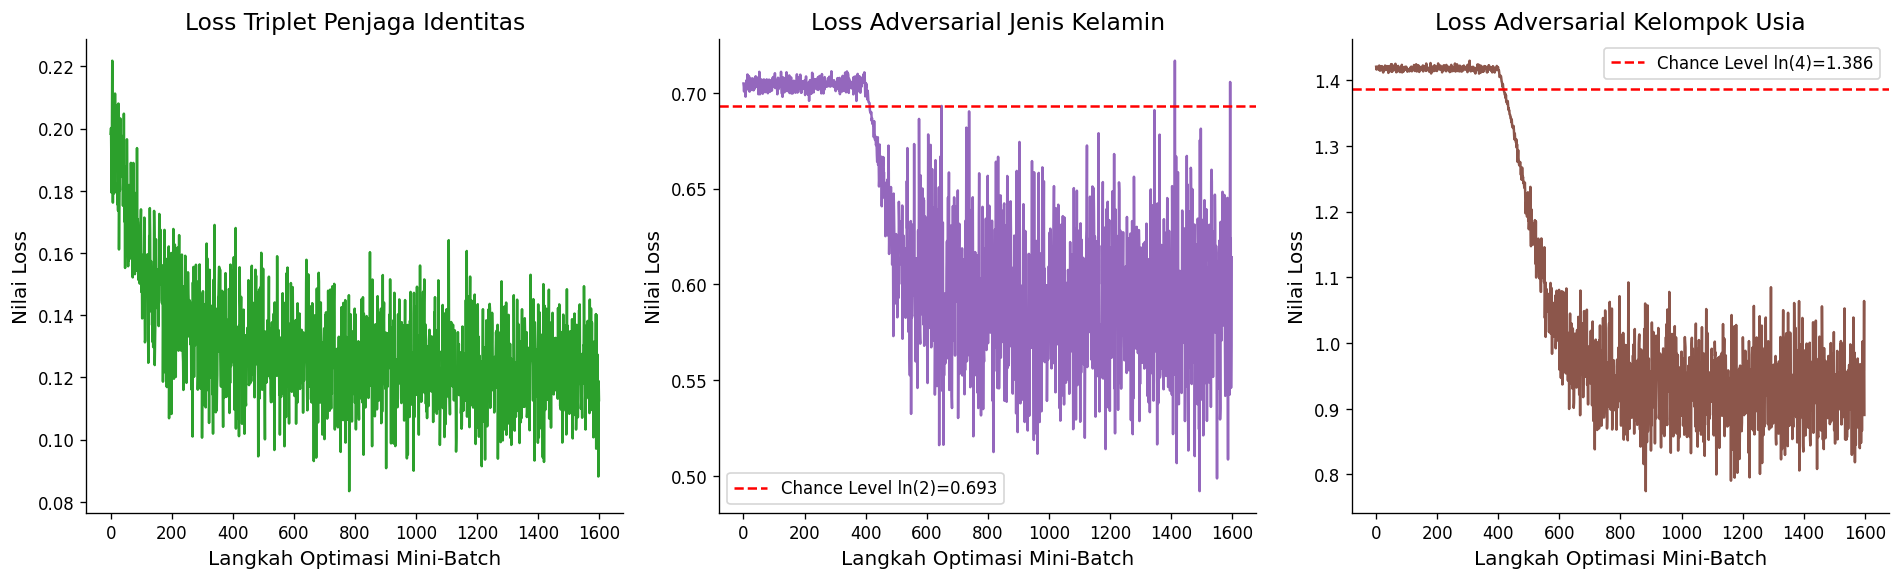

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(history["triplet_loss"], color=COLOR_PROPOSED)
axes[0].set_title("Loss Triplet Penjaga Identitas")
axes[0].set_xlabel("Langkah Optimasi Mini-Batch")
axes[0].set_ylabel("Nilai Loss")

axes[1].plot(history["gender_loss"], color=COLOR_ACCENT)
axes[1].axhline(np.log(2.0), color="red", linestyle="--", linewidth=1.5, label="Chance Level ln(2)=0.693")
axes[1].set_title("Loss Adversarial Jenis Kelamin")
axes[1].set_xlabel("Langkah Optimasi Mini-Batch")
axes[1].set_ylabel("Nilai Loss")
axes[1].legend()

axes[2].plot(history["age_loss"], color=COLOR_NEUTRAL)
axes[2].axhline(np.log(4.0), color="red", linestyle="--", linewidth=1.5, label="Chance Level ln(4)=1.386")
axes[2].set_title("Loss Adversarial Kelompok Usia")
axes[2].set_xlabel("Langkah Optimasi Mini-Batch")
axes[2].set_ylabel("Nilai Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

## Basis Data Terlindungi
Hanya template yang disimpan, foto asli tidak. Note: satu kunci dipakai untuk seluruh database.

In [ ]:
protected_database = pd.DataFrame({
    "identity": gallery_identities_array,
    "template_rp": list(gallery_rp),
    "template_bh": list(gallery_bh),
    "template_proposed": list(gallery_proposed),
})
print("Ancamam threat model: Penggunaan kunci tunggal bersama untuk seluruh gallery berisiko kompromi massal jika kunci terkompromi.")
print(protected_database.shape)
protected_database.head()

Ancamam threat model: Penggunaan kunci tunggal bersama untuk seluruh gallery berisiko kompromi massal jika kunci terkompromi.
(1620, 4)


,identity,template_rp,template_bh,template_proposed
0,9104,"[-0.0517267399483939, -0.033796908155359545, 0...","[1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, ...","[0.041098004973331034, -0.043219798876598485, ..."
1,9961,"[-0.018302148902599773, -0.046917698478634154,...","[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[-0.0975028857396536, 0.05870634162939698, 0.0..."
2,8842,"[-0.05135796496723479, -0.07226573792271067, 0...","[1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1142553044495134, -0.014208216497602224, 0...."
3,9985,"[-0.11183715205403037, -0.014218095413511175, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[-0.06391549318119923, 0.09532096169158909, 0...."
4,9578,"[-0.12258674705776974, 0.04938625157081274, 0....","[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...","[0.012352818731097219, 0.02946534758985785, -0..."


## Protokol Pencarian 1:N dan Pengungkapan Selektif
Foto pelaku dibandingkan dengan seluruh isi database, lalu diurutkan berdasarkan kemiripan. Hanya yang melewati ambang batas tertentu yang datanya "dibuka", sisanya tetap terkunci. Ini adalah bentuk teknis dari prinsip minimalisasi data di UU PDP No. 27/2022.


In [ ]:
def identification_search(probe_templates, gallery_templates, gallery_identities, similarity_fn):
    similarity = similarity_fn(probe_templates, gallery_templates)
    ranking = np.argsort(-similarity, axis=1)
    ranked_identities = gallery_identities[ranking]
    ranked_scores = np.take_along_axis(similarity, ranking, axis=1)
    return ranked_identities, ranked_scores

def selective_disclosure(ranked_identities, ranked_scores, threshold):
    disclosed = ranked_scores[:, 0] >= threshold
    disclosed_identity = np.where(disclosed, ranked_identities[:, 0], "TERKUNCI")
    return disclosed, disclosed_identity

METHODS = {
    "Random Projection": {"gallery": gallery_rp, "mated": mated_rp, "unmated": unmated_rp, "similarity_fn": cosine_similarity_matrix, "color": COLOR_BASELINE_RP},
    "BioHashing": {"gallery": gallery_bh, "mated": mated_bh, "unmated": unmated_bh, "similarity_fn": hamming_similarity_matrix, "color": COLOR_BASELINE_BH},
    "Metode Usulan": {"gallery": gallery_proposed, "mated": mated_proposed, "unmated": unmated_proposed, "similarity_fn": cosine_similarity_matrix, "color": COLOR_PROPOSED},
}

search_results = {}
for method_name, cfg in METHODS.items():
    mated_ranked_ids, mated_ranked_scores = identification_search(cfg["mated"], cfg["gallery"], gallery_identities_array, cfg["similarity_fn"])
    unmated_ranked_ids, unmated_ranked_scores = identification_search(cfg["unmated"], cfg["gallery"], gallery_identities_array, cfg["similarity_fn"])
    search_results[method_name] = {
        "mated_ranked_ids": mated_ranked_ids,
        "mated_ranked_scores": mated_ranked_scores,
        "unmated_ranked_ids": unmated_ranked_ids,
        "unmated_ranked_scores": unmated_ranked_scores,
    }

example_threshold = float(np.median(search_results["Metode Usulan"]["mated_ranked_scores"][:, 0]))
disclosed_flags, disclosed_identities = selective_disclosure(
    search_results["Metode Usulan"]["mated_ranked_ids"],
    search_results["Metode Usulan"]["mated_ranked_scores"],
    example_threshold,
)
print("Ambang batas pengungkapan selektif:", example_threshold)
print("Proporsi identitas terungkap:", disclosed_flags.mean())

Ambang batas pengungkapan selektif: 0.5180023213426393
Proporsi identitas terungkap: 0.5


## Evaluasi Identifikasi 1:N (CMC dan DIR/FPIR)
CMC mengukur seberapa sering target ada di dalam hasil teratas (top-k). DIR/FPIR mengukur seberapa banyak target yang terdeteksi pada berbagai tingkat alarm palsu. Dua grafik ini adalah standar evaluasi sistem identifikasi biometrik open-set (Phillips et al., NIST).

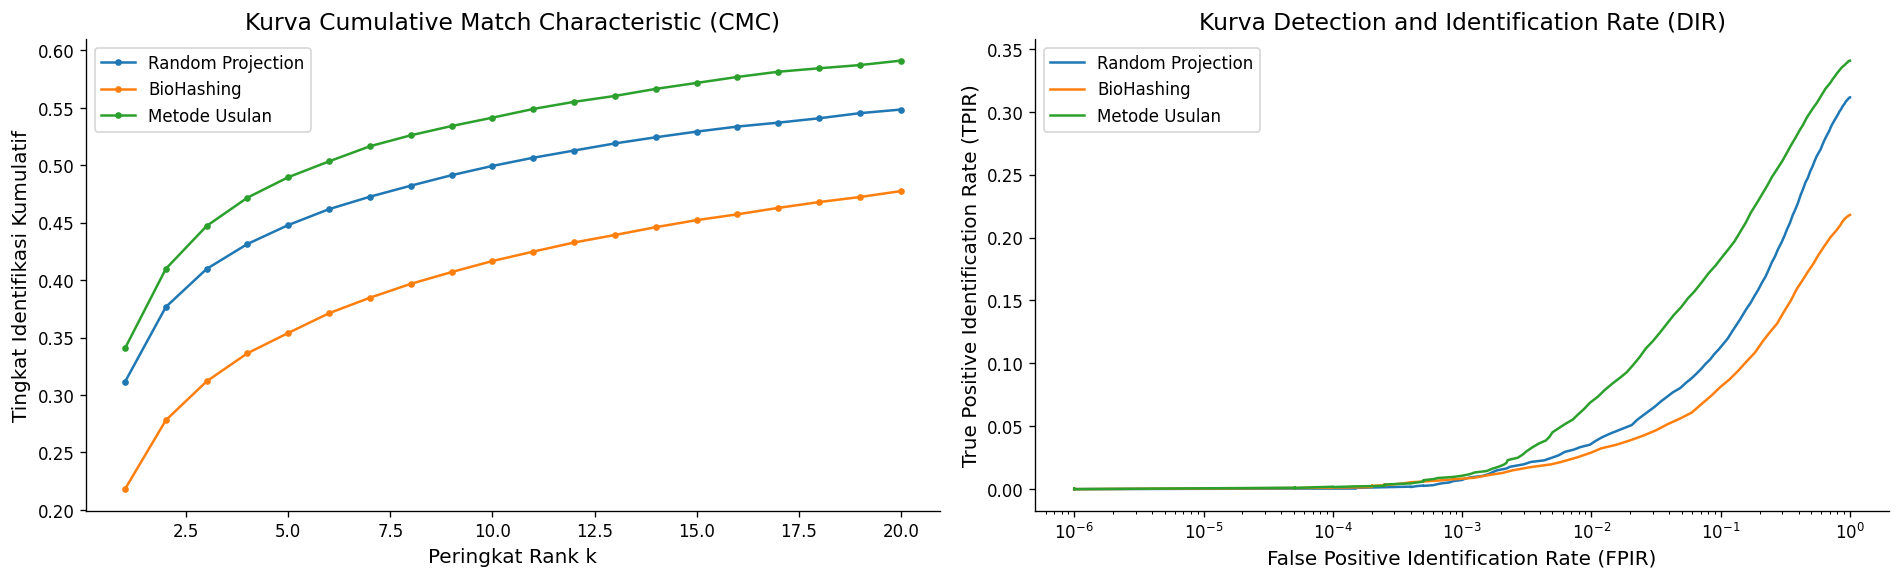

,Metode,TPIR pada FPIR 0.2,TPIR pada FPIR 0.1,TPIR pada FPIR 0.05,TPIR pada FPIR 0.01,Rank 1 Accuracy,Rank 5 Accuracy
0,Random Projection,0.160542,0.112898,0.081407,0.036070,0.3114,0.447933
1,BioHashing,0.113746,0.081422,0.056741,0.029133,0.2180,0.354000
2,Metode Usulan,0.231026,0.182987,0.145281,0.069489,0.3406,0.489600


In [ ]:
def compute_cmc(ranked_ids, true_ids, max_rank):
    cmc = np.zeros(max_rank)
    for k in range(1, max_rank + 1):
        hits = (ranked_ids[:, :k] == true_ids[:, None]).any(axis=1)
        cmc[k - 1] = hits.mean()
    return cmc

def compute_tpir_fpir(mated_ranked_ids, mated_ranked_scores, mated_true_ids, unmated_ranked_scores, thresholds):
    rank1_correct = mated_ranked_ids[:, 0] == mated_true_ids
    mated_top_score = mated_ranked_scores[:, 0]
    unmated_top_score = unmated_ranked_scores[:, 0]
    tpir_list, fpir_list = [], []
    for th in thresholds:
        accepted_and_correct = (mated_top_score >= th) & rank1_correct
        tpir_list.append(accepted_and_correct.mean())
        fpir_list.append((unmated_top_score >= th).mean())
    return np.array(tpir_list), np.array(fpir_list)

def tpir_at_fpir(fpir_vals, tpir_vals, target_fpir):
    order = np.argsort(fpir_vals)
    return float(np.interp(target_fpir, fpir_vals[order], tpir_vals[order]))

true_mated_ids = mated_df["identity"].to_numpy(dtype=object)
cmc_curves = {}
dir_curves = {}
for method_name in METHODS:
    ranked_ids = search_results[method_name]["mated_ranked_ids"]
    cmc_curves[method_name] = compute_cmc(ranked_ids, true_mated_ids, MAX_RANK)
    m_scores = search_results[method_name]["mated_ranked_scores"]
    u_scores = search_results[method_name]["unmated_ranked_scores"]
    th_range = np.linspace(min(m_scores.min(), u_scores.min()), max(m_scores.max(), u_scores.max()), 300)
    tpir, fpir = compute_tpir_fpir(ranked_ids, m_scores, true_mated_ids, u_scores, th_range)
    dir_curves[method_name] = {"tpir": tpir, "fpir": fpir}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for method_name, cfg in METHODS.items():
    axes[0].plot(range(1, MAX_RANK + 1), cmc_curves[method_name], label=method_name, color=cfg["color"], marker="o", markersize=3)
axes[0].set_title("Kurva Cumulative Match Characteristic (CMC)")
axes[0].set_xlabel("Peringkat Rank k")
axes[0].set_ylabel("Tingkat Identifikasi Kumulatif")
axes[0].legend()

for method_name, cfg in METHODS.items():
    f_v = dir_curves[method_name]["fpir"]
    t_v = dir_curves[method_name]["tpir"]
    ord_i = np.argsort(f_v)
    axes[1].plot(f_v[ord_i] + 1e-6, t_v[ord_i], label=method_name, color=cfg["color"])
axes[1].set_title("Kurva Detection and Identification Rate (DIR)")
axes[1].set_xlabel("False Positive Identification Rate (FPIR)")
axes[1].set_ylabel("True Positive Identification Rate (TPIR)")
axes[1].set_xscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

summary_rows = []
for method_name in METHODS:
    row = {"Metode": method_name}
    for target in TARGET_FPIR_POINTS:
        row[f"TPIR pada FPIR {target}"] = tpir_at_fpir(dir_curves[method_name]["fpir"], dir_curves[method_name]["tpir"], target)
    row["Rank 1 Accuracy"] = cmc_curves[method_name][0]
    row["Rank 5 Accuracy"] = cmc_curves[method_name][4]
    summary_rows.append(row)
identification_summary_df = pd.DataFrame(summary_rows)
identification_summary_df

## Interval Kepercayaan Bootstrap
Bootstrap dijalankan dengan cara resampling per identitas (bukan per foto) agar varians yang dihitung akurat. Paired bootstrap dipakai untuk menguji apakah perbedaan performa antar metode betul-betul signifikan atau hanya kebetulan.


Paired Bootstrap Difference (Metode Usulan - RP): 0.0292 [95% CI: 0.0176, 0.0411]


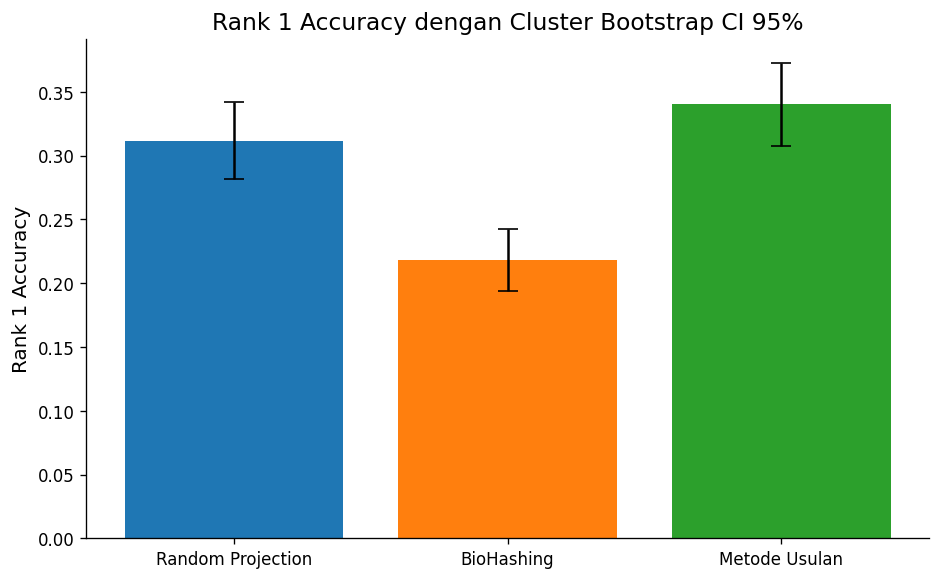

,Metode,Rank 1 Accuracy,Batas Bawah,Batas Atas
0,Random Projection,0.3114,0.281580,0.341968
1,BioHashing,0.2180,0.194123,0.242424
2,Metode Usulan,0.3406,0.307505,0.372661


In [ ]:
def cluster_block_bootstrap_ci(identities, correct_mask, n_boot=1000, ci_level=95, seed=42):
    generator = np.random.default_rng(seed)
    unique_ids = np.unique(identities)
    n_clusters = len(unique_ids)
    id_to_indices = {uid: np.where(identities == uid)[0] for uid in unique_ids}
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        boot_ids = generator.choice(unique_ids, size=n_clusters, replace=True)
        boot_indices = np.concatenate([id_to_indices[uid] for uid in boot_ids])
        boot_means[i] = correct_mask[boot_indices].mean()
    low_pct = (100 - ci_level) / 2.0
    high_pct = 100 - low_pct
    return correct_mask.mean(), np.percentile(boot_means, low_pct), np.percentile(boot_means, high_pct)

def paired_bootstrap_diff(identities, mask_a, mask_b, n_boot=1000, ci_level=95, seed=42):
    generator = np.random.default_rng(seed)
    unique_ids = np.unique(identities)
    n_clusters = len(unique_ids)
    id_to_indices = {uid: np.where(identities == uid)[0] for uid in unique_ids}
    diff_means = np.empty(n_boot)
    for i in range(n_boot):
        boot_ids = generator.choice(unique_ids, size=n_clusters, replace=True)
        boot_indices = np.concatenate([id_to_indices[uid] for uid in boot_ids])
        diff_means[i] = mask_a[boot_indices].mean() - mask_b[boot_indices].mean()
    low_pct = (100 - ci_level) / 2.0
    high_pct = 100 - low_pct
    mean_diff = mask_a.mean() - mask_b.mean()
    return mean_diff, np.percentile(diff_means, low_pct), np.percentile(diff_means, high_pct)

rank1_ci_rows = []
for method_name in METHODS:
    r_ids = search_results[method_name]["mated_ranked_ids"]
    c_mask = (r_ids[:, 0] == true_mated_ids).astype(float)
    m_val, low, high = cluster_block_bootstrap_ci(true_mated_ids, c_mask, N_BOOTSTRAP, CI_LEVEL, RANDOM_SEED)
    rank1_ci_rows.append({"Metode": method_name, "Rank 1 Accuracy": m_val, "Batas Bawah": low, "Batas Atas": high})
rank1_ci_df = pd.DataFrame(rank1_ci_rows)

mask_proposed = (search_results["Metode Usulan"]["mated_ranked_ids"][:, 0] == true_mated_ids).astype(float)
mask_rp = (search_results["Random Projection"]["mated_ranked_ids"][:, 0] == true_mated_ids).astype(float)
mean_d, low_d, high_d = paired_bootstrap_diff(true_mated_ids, mask_proposed, mask_rp, N_BOOTSTRAP, CI_LEVEL, RANDOM_SEED)
print(f"Paired Bootstrap Difference (Metode Usulan - RP): {mean_d:.4f} [95% CI: {low_d:.4f}, {high_d:.4f}]")

plt.figure(figsize=(8, 5))
x_pos = np.arange(len(rank1_ci_df))
plt.bar(
    x_pos,
    rank1_ci_df["Rank 1 Accuracy"],
    yerr=[rank1_ci_df["Rank 1 Accuracy"] - rank1_ci_df["Batas Bawah"], rank1_ci_df["Batas Atas"] - rank1_ci_df["Rank 1 Accuracy"]],
    capsize=6,
    color=[METHODS[m]["color"] for m in rank1_ci_df["Metode"]],
)
plt.xticks(x_pos, rank1_ci_df["Metode"])
plt.title(f"Rank 1 Accuracy dengan Cluster Bootstrap CI {CI_LEVEL}%")
plt.ylabel("Rank 1 Accuracy")
plt.tight_layout()
plt.show()
rank1_ci_df

## Uji Standar ISO/IEC 24745
Standar internasional untuk sistem cancelable biometrics mensyaratkan 4 properti. Dua sudah diuji di bagian lain (irreversibility dan performance). Bagian ini menguji dua sisanya: unlinkability (apakah template dua orang berbeda bisa dibedakan distribusinya) dan revocability (kalau kunci diganti, apakah template lama dan baru benar-benar tidak bisa dicocokkan).


In [ ]:
def evaluate_unlinkability(mated_scores, unmated_scores):
    ks_stat, p_val = ks_2samp(mated_scores, unmated_scores)
    hist_m, bin_edges = np.histogram(mated_scores, bins=50, density=True)
    hist_u, _ = np.histogram(unmated_scores, bins=bin_edges, density=True)
    overlap = np.sum(np.minimum(hist_m, hist_u) * np.diff(bin_edges))
    return float(ks_stat), float(p_val), float(overlap)

revocation_rp_key = generate_key_matrix(REVOCATION_KEY_SEED, EMBEDDING_DIM, TEMPLATE_DIM)
revocation_gallery_rp = random_projection_transform(gallery_embeddings, revocation_rp_key)
with torch.no_grad():
    revocation_gallery_proposed = proposed_net(torch.tensor(revocation_gallery_rp, dtype=torch.float32).to(DEVICE)).cpu().numpy()

cross_sim_proposed = np.sum(gallery_proposed * revocation_gallery_proposed, axis=1)
revocability_cross_match_rate = float((cross_sim_proposed > 0.5).mean())

ks_stat_prop, p_val_prop, overlap_prop = evaluate_unlinkability(
    search_results["Metode Usulan"]["mated_ranked_scores"][:, 0],
    search_results["Metode Usulan"]["unmated_ranked_scores"][:, 0]
)

iso_summary_df = pd.DataFrame([{
    "Metode": "Metode Usulan",
    "KS Statistic Unlinkability": ks_stat_prop,
    "Overlap Coefficient": overlap_prop,
    "Revocability Cross-Match Rate": revocability_cross_match_rate
}])
print("Hasil Uji ISO/IEC 24745 Unlinkability dan Revocability:")
iso_summary_df

Hasil Uji ISO/IEC 24745 Unlinkability dan Revocability:


,Metode,KS Statistic Unlinkability,Overlap Coefficient,Revocability Cross-Match Rate
0,Metode Usulan,0.182283,0.818033,0.0


## Serangan Rekonstruksi
Sebuah decoder dilatih untuk mencoba mengembalikan embedding asli dari template terlindungi, mengikuti pendekatan Shahreza & Marcel (Idiap, 2022–2024). Semakin rendah kemiripan hasil rekonstruksi dengan embedding asli, semakin aman template-nya.


In [ ]:
class TemplateDecoder(nn.Module):
    def __init__(self, template_dim, embedding_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(template_dim, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim),
        )

    def forward(self, x):
        out = self.net(x)
        return F.normalize(out, p=2, dim=1)

def train_decoder(templates, targets, epochs, lr, seed):
    torch.manual_seed(seed)
    decoder = TemplateDecoder(templates.shape[1], targets.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(decoder.parameters(), lr=lr)
    loss_fn = nn.CosineEmbeddingLoss()
    templates_tensor = torch.tensor(templates, dtype=torch.float32).to(DEVICE)
    targets_tensor = torch.tensor(targets, dtype=torch.float32).to(DEVICE)
    ones = torch.ones(templates_tensor.shape[0]).to(DEVICE)
    loss_history = []
    for epoch in range(epochs):
        reconstructed = decoder(templates_tensor)
        loss = loss_fn(reconstructed, targets_tensor, ones)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return decoder, loss_history

DECODER_EPOCHS = 150
DECODER_LR = 1e-3

reconstruction_target_ids = set(mated_df["identity"].unique())
eval_mask = np.isin(gallery_identities_array, list(reconstruction_target_ids))
N_eff_reconstruction = int(eval_mask.sum())
print(f"Ukuran sampel efektif N_eff untuk serangan rekonstruksi: {N_eff_reconstruction} identitas")

decoders = {}
decoder_histories = {}
for method_name in METHODS:
    if method_name == "Random Projection":
        method_train_t = training_rp
    elif method_name == "BioHashing":
        method_train_t = training_bh
    else:
        with torch.no_grad():
            method_train_t = proposed_net(training_rp_tensor).cpu().numpy()
    decoder, loss_hist = train_decoder(method_train_t, training_embeddings, DECODER_EPOCHS, DECODER_LR, RANDOM_SEED)
    decoders[method_name] = decoder
    decoder_histories[method_name] = loss_hist

def evaluate_reconstruction(decoder, protected_templates, true_embeddings, reference_embeddings, reference_identities, protected_identities):
    with torch.no_grad():
        reconstructed = decoder(torch.tensor(protected_templates, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    cosine_to_true = np.sum(reconstructed * true_embeddings, axis=1)
    similarity_to_reference = reconstructed @ reference_embeddings.T
    nearest_idx = np.argmax(similarity_to_reference, axis=1)
    predicted_identity = reference_identities[nearest_idx]
    reid_success = predicted_identity == protected_identities
    return cosine_to_true, reid_success

reconstruction_results = {}
for method_name in METHODS:
    if method_name == "Random Projection":
        g_t = gallery_rp
    elif method_name == "BioHashing":
        g_t = gallery_bh
    else:
        g_t = gallery_proposed
    cos_true, reid_succ = evaluate_reconstruction(
        decoders[method_name],
        g_t[eval_mask],
        gallery_embeddings[eval_mask],
        mated_embeddings,
        mated_df["identity"].to_numpy(dtype=object),
        gallery_identities_array[eval_mask],
    )
    reconstruction_results[method_name] = {"cosine_to_true": cos_true, "reid_success": reid_succ}

reconstruction_summary_df = pd.DataFrame([
    {
        "Metode": method_name,
        "Rata Rata Kemiripan Kosinus": reconstruction_results[method_name]["cosine_to_true"].mean(),
        "Tingkat Keberhasilan Reidentifikasi": reconstruction_results[method_name]["reid_success"].mean(),
        "Ukuran Sampel N_eff": N_eff_reconstruction,
    }
    for method_name in METHODS
])
reconstruction_summary_df

Ukuran sampel efektif N_eff untuk serangan rekonstruksi: 1057 identitas


,Metode,Rata Rata Kemiripan Kosinus,Tingkat Keberhasilan Reidentifikasi,Ukuran Sampel N_eff
0,Random Projection,0.907977,0.294229,1057
1,BioHashing,0.768396,0.177862,1057
2,Metode Usulan,0.068716,0.000000,1057


## Serangan Penebakan Atribut
Classifier dilatih untuk menebak gender dan usia hanya dari template, mengikuti Osorio Roig et al. (2022). Catatan: label gender dan usia berasal dari model InsightFace (pseudo-label), bukan anotasi manual, jadi hasilnya mencerminkan seberapa baik informasi itu bisa ditebak dari template, bukan dari atribut asli orangnya.


In [ ]:
class AttributeClassifier(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 128), nn.ReLU(), nn.Linear(128, n_classes))

    def forward(self, x):
        return self.net(x)

def train_attribute_attack(train_templates, train_labels, n_classes, epochs, lr, seed):
    torch.manual_seed(seed)
    model = AttributeClassifier(train_templates.shape[1], n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    templates_tensor = torch.tensor(train_templates, dtype=torch.float32).to(DEVICE)
    labels_tensor = torch.tensor(train_labels, dtype=torch.long).to(DEVICE)
    for epoch in range(epochs):
        logits = model(templates_tensor)
        loss = loss_fn(logits, labels_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

def evaluate_attribute_attack(model, test_templates, test_labels):
    with torch.no_grad():
        logits = model(torch.tensor(test_templates, dtype=torch.float32).to(DEVICE))
        predictions = logits.argmax(dim=1).cpu().numpy()
    accuracy = (predictions == test_labels).mean()
    return predictions, accuracy

ATTACK_EPOCHS = 150
ATTACK_LR = 1e-3

gallery_unique_df = gallery_df.groupby("identity").first().reindex(gallery_identities_array).reset_index()

attribute_attack_results = {}
for method_name in METHODS:
    if method_name == "Random Projection":
        tr_t = training_rp
        gl_t = gallery_rp
    elif method_name == "BioHashing":
        tr_t = training_bh
        gl_t = gallery_bh
    else:
        with torch.no_grad():
            tr_t = proposed_net(training_rp_tensor).cpu().numpy()
        gl_t = gallery_proposed
    g_model = train_attribute_attack(tr_t, training_df["pseudo_gender"].values, 2, ATTACK_EPOCHS, ATTACK_LR, RANDOM_SEED)
    a_model = train_attribute_attack(tr_t, training_df["age_bucket"].values, len(AGE_BUCKET_LABELS), ATTACK_EPOCHS, ATTACK_LR, RANDOM_SEED)
    g_preds, g_acc = evaluate_attribute_attack(g_model, gl_t, gallery_unique_df["pseudo_gender"].values)
    a_preds, a_acc = evaluate_attribute_attack(a_model, gl_t, gallery_unique_df["age_bucket"].values)
    attribute_attack_results[method_name] = {"gender_accuracy": g_acc, "age_accuracy": a_acc, "gender_predictions": g_preds}

print("Catatan rigor: Baik defender maupun attacker menggunakan sumber pseudo-label InsightFace yang sama.")
attack_summary_df = pd.DataFrame([
    {
        "Metode": method_name,
        "Akurasi Tebakan Jenis Kelamin": attribute_attack_results[method_name]["gender_accuracy"],
        "Akurasi Tebakan Kelompok Usia": attribute_attack_results[method_name]["age_accuracy"],
    }
    for method_name in METHODS
])
attack_summary_df

Catatan rigor: Baik defender maupun attacker menggunakan sumber pseudo-label InsightFace yang sama.


,Metode,Akurasi Tebakan Jenis Kelamin,Akurasi Tebakan Kelompok Usia
0,Random Projection,0.655556,0.579012
1,BioHashing,0.658025,0.563580
2,Metode Usulan,0.566667,0.439506


## Studi Ablasi Dimensi Template Biometrics (TEMPLATE_DIM)
Uji coba dengan ukuran template 64, 128, 256, dan 512 dimensi untuk melihat trade-off antara akurasi pencarian dan ukuran template yang lebih kecil.


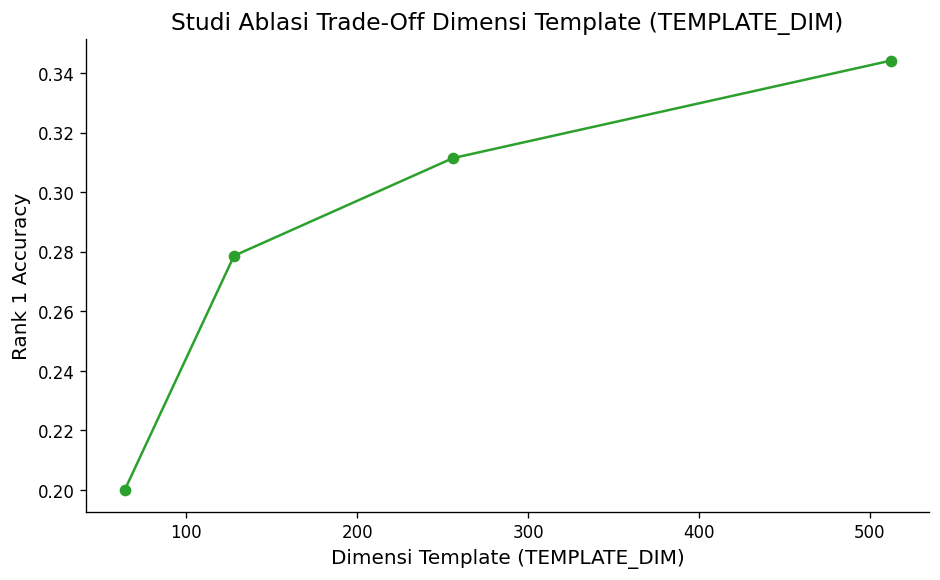

,TEMPLATE_DIM,Rank 1 Accuracy
0,64,0.199867
1,128,0.278600
2,256,0.311400
3,512,0.344133


In [ ]:
TEMPLATE_DIMS = [64, 128, 256, 512]
ablation_rows = []
for dim in TEMPLATE_DIMS:
    rp_k = generate_key_matrix(INSTITUTION_KEY_SEED, EMBEDDING_DIM, dim)
    g_rp_d = random_projection_transform(gallery_embeddings, rp_k)
    m_rp_d = random_projection_transform(mated_embeddings, rp_k)
    sim_d = cosine_similarity_matrix(m_rp_d, g_rp_d)
    rank1_d = (gallery_identities_array[np.argsort(-sim_d, axis=1)[:, 0]] == true_mated_ids).mean()
    ablation_rows.append({"TEMPLATE_DIM": dim, "Rank 1 Accuracy": rank1_d})

ablation_df = pd.DataFrame(ablation_rows)
plt.figure(figsize=(8, 5))
plt.plot(ablation_df["TEMPLATE_DIM"], ablation_df["Rank 1 Accuracy"], marker="o", color=COLOR_PROPOSED)
plt.title("Studi Ablasi Trade-Off Dimensi Template (TEMPLATE_DIM)")
plt.xlabel("Dimensi Template (TEMPLATE_DIM)")
plt.ylabel("Rank 1 Accuracy")
plt.tight_layout()
plt.show()
ablation_df

## Analisis Ketahanan terhadap Variasi Kualitas Kamera CCTV
Foto probe dibagi ke tiga kelompok kualitas berdasarkan ketajaman gambar. Tujuannya melihat seberapa jauh performa sistem turun kalau foto yang dipakai buram atau resolusinya rendah.


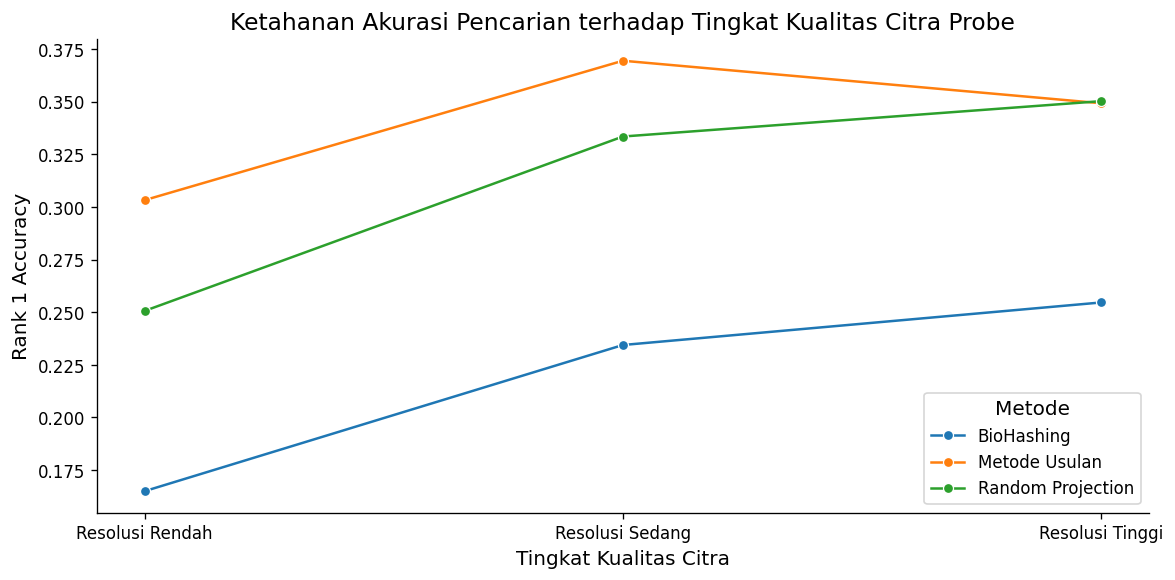

,Metode,Tingkat Kualitas,Rank 1 Accuracy,Jumlah Sampel
3,BioHashing,Resolusi Rendah,0.1650,5000
4,BioHashing,Resolusi Sedang,0.2344,5000
5,BioHashing,Resolusi Tinggi,0.2546,5000
6,Metode Usulan,Resolusi Rendah,0.3032,5000
7,Metode Usulan,Resolusi Sedang,0.3694,5000
8,Metode Usulan,Resolusi Tinggi,0.3492,5000
0,Random Projection,Resolusi Rendah,0.2506,5000
1,Random Projection,Resolusi Sedang,0.3334,5000
2,Random Projection,Resolusi Tinggi,0.3502,5000


In [ ]:
QUALITY_LABELS = ["Resolusi Rendah", "Resolusi Sedang", "Resolusi Tinggi"]
quality_stats_full = [compute_image_stats(p) for p in mated_df["path"]]
mated_df["laplacian_var"] = [s["laplacian_var"] for s in quality_stats_full]
quality_edges = np.quantile(mated_df["laplacian_var"].dropna(), [0, 1/3, 2/3, 1.0])
mated_df["quality_bin"] = pd.cut(mated_df["laplacian_var"], bins=quality_edges, labels=QUALITY_LABELS, include_lowest=True)

robustness_rows = []
for method_name, cfg in METHODS.items():
    for quality_level in QUALITY_LABELS:
        mask = (mated_df["quality_bin"] == quality_level).values
        if mask.sum() == 0:
            continue
        true_ids_q = mated_df.loc[mask, "identity"].to_numpy(dtype=object)
        probe_t = cfg["mated"][mask]
        similarity = cfg["similarity_fn"](probe_t, cfg["gallery"])
        ranking = np.argsort(-similarity, axis=1)
        ranked_ids = gallery_identities_array[ranking]
        rank1 = (ranked_ids[:, 0] == true_ids_q).mean()
        robustness_rows.append({"Metode": method_name, "Tingkat Kualitas": quality_level, "Rank 1 Accuracy": rank1, "Jumlah Sampel": int(mask.sum())})

robustness_df = pd.DataFrame(robustness_rows)
robustness_df["Tingkat Kualitas"] = pd.Categorical(robustness_df["Tingkat Kualitas"], categories=QUALITY_LABELS, ordered=True)
robustness_df = robustness_df.sort_values(["Metode", "Tingkat Kualitas"])

plt.figure(figsize=(10, 5))
sns.lineplot(data=robustness_df, x="Tingkat Kualitas", y="Rank 1 Accuracy", hue="Metode", marker="o", palette=[METHODS[m]["color"] for m in METHODS], sort=False)
plt.title("Ketahanan Akurasi Pencarian terhadap Tingkat Kualitas Citra Probe")
plt.xlabel("Tingkat Kualitas Citra")
plt.ylabel("Rank 1 Accuracy")
plt.tight_layout()
plt.show()
robustness_df

## Perbandingan Akhir dan Ekspor Hasil
Semua metrik dari seluruh bagian dikumpulkan dalam satu tabel dan ditampilkan sebagai heatmap perbandingan. Hasilnya juga diekspor ke folder `assets`.

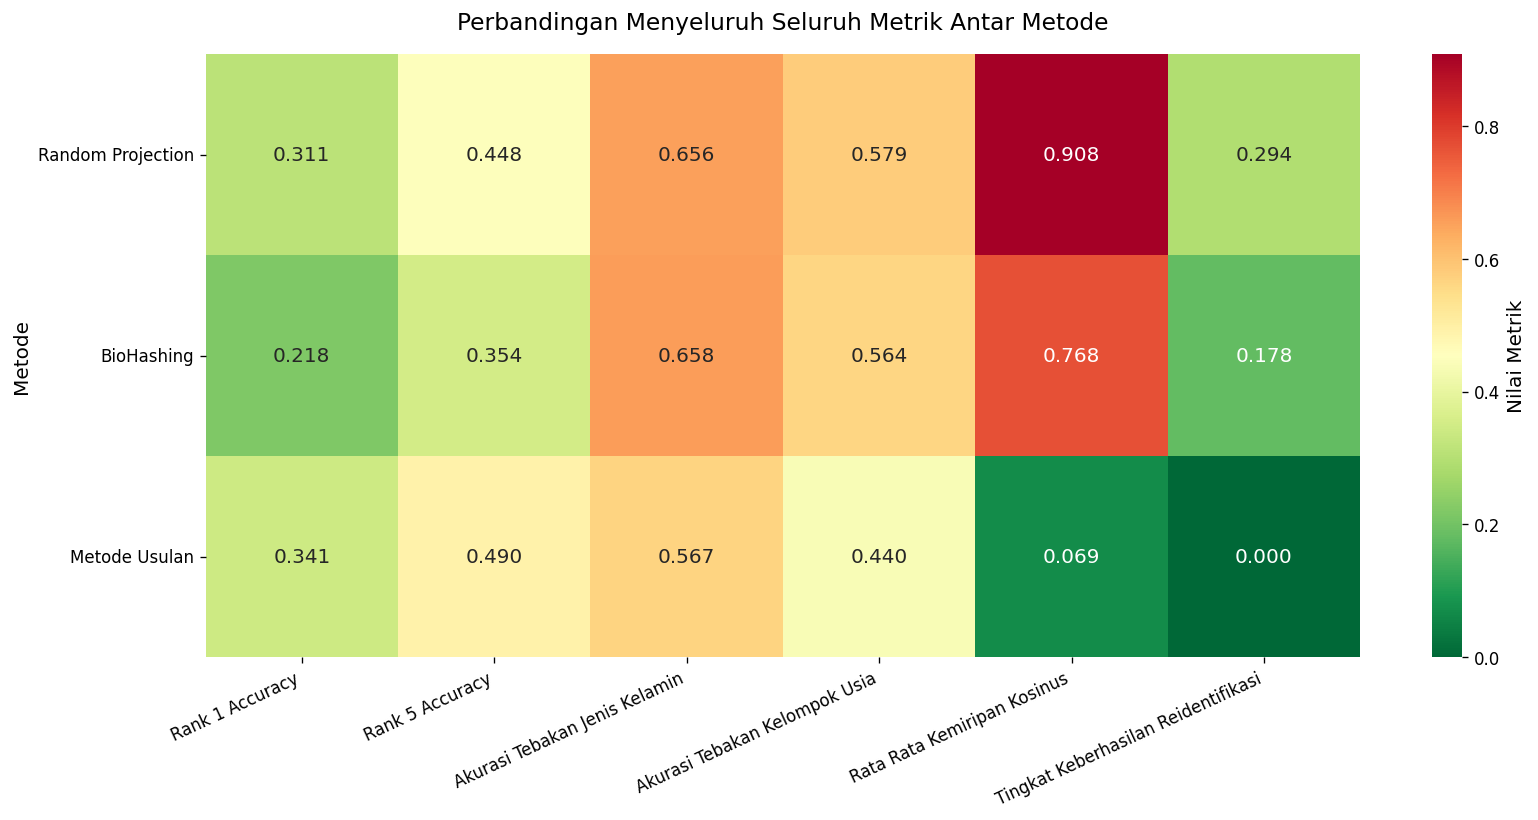

Seluruh hasil eksperimen berhasil diekspor ke folder: assets


,Metode,TPIR pada FPIR 0.2,TPIR pada FPIR 0.1,TPIR pada FPIR 0.05,TPIR pada FPIR 0.01,Rank 1 Accuracy,Rank 5 Accuracy,Akurasi Tebakan Jenis Kelamin,Akurasi Tebakan Kelompok Usia,Rata Rata Kemiripan Kosinus,Tingkat Keberhasilan Reidentifikasi,Ukuran Sampel N_eff
0,Random Projection,0.160542,0.112898,0.081407,0.036070,0.3114,0.447933,0.655556,0.579012,0.907977,0.294229,1057
1,BioHashing,0.113746,0.081422,0.056741,0.029133,0.2180,0.354000,0.658025,0.563580,0.768396,0.177862,1057
2,Metode Usulan,0.231026,0.182987,0.145281,0.069489,0.3406,0.489600,0.566667,0.439506,0.068716,0.000000,1057


In [ ]:
final_comparison_df = identification_summary_df.merge(attack_summary_df, on="Metode").merge(reconstruction_summary_df, on="Metode")
comparison_metrics = [
    "Rank 1 Accuracy",
    "Rank 5 Accuracy",
    "Akurasi Tebakan Jenis Kelamin",
    "Akurasi Tebakan Kelompok Usia",
    "Rata Rata Kemiripan Kosinus",
    "Tingkat Keberhasilan Reidentifikasi",
]
heatmap_data = final_comparison_df.set_index("Metode")[comparison_metrics].astype(float)

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn_r", cbar_kws={"label": "Nilai Metrik"})
plt.title("Perbandingan Menyeluruh Seluruh Metrik Antar Metode", pad=15)
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

output_dir = "assets"
os.makedirs(output_dir, exist_ok=True)
final_comparison_df.to_csv(os.path.join(output_dir, "ringkasan_perbandingan_metode.csv"), index=False)
identification_summary_df.to_csv(os.path.join(output_dir, "ringkasan_identifikasi.csv"), index=False)
attack_summary_df.to_csv(os.path.join(output_dir, "ringkasan_serangan_atribut.csv"), index=False)
reconstruction_summary_df.to_csv(os.path.join(output_dir, "ringkasan_serangan_rekonstruksi.csv"), index=False)
robustness_df.to_csv(os.path.join(output_dir, "ketahanan_kualitas_pencarian.csv"), index=False)
iso_summary_df.to_csv(os.path.join(output_dir, "ringkasan_iso_24745.csv"), index=False)
ablation_df.to_csv(os.path.join(output_dir, "ablasi_dimensi_template.csv"), index=False)
print("Seluruh hasil eksperimen berhasil diekspor ke folder:", output_dir)
final_comparison_df

In [ ]:
export_dir = "assets"
os.makedirs(export_dir, exist_ok=True)

torch.save(proposed_net.state_dict(), os.path.join(export_dir, "proposed_net.pt"))

np.save(os.path.join(export_dir, "rp_key_matrix.npy"), rp_key_matrix)
np.save(os.path.join(export_dir, "perm_key_matrix.npy"), perm_key_matrix)

np.save(os.path.join(export_dir, "gallery_proposed.npy"), gallery_proposed)
np.save(os.path.join(export_dir, "gallery_identities.npy"), gallery_identities_array)

dashboard_meta = {
    "TEMPLATE_DIM": TEMPLATE_DIM,
    "EMBEDDING_DIM": EMBEDDING_DIM,
    "INSTITUTION_KEY_SEED": INSTITUTION_KEY_SEED,
    "RANDOM_SEED": RANDOM_SEED,
    "unique_train_ids": unique_train_ids.tolist(),
    "id_to_label_map": id_to_label_map
}

with open(os.path.join(export_dir, "metadata.pkl"), "wb") as f:
    pickle.dump(dashboard_meta, f)

shutil.make_archive("assets", "zip", export_dir)

print("Seluruh asset live demo berhasil dikompres ke assets.zip! Memulai download...")
files.download("assets.zip")

Seluruh asset live demo berhasil dikompres ke assets.zip! Memulai download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>